<div style="font-family:'Georgia','Times New Roman',Times,serif; width:80%; margin:20px auto; padding:10px 20px 20px 20px; background:#ffffff; border-left:20px solid #003366; box-shadow:0 5px 20px rgba(0,0,0,0.1); text-align:center; border-radius:8px;">

  <div style="display:flex; align-items:center; justify-content:center; gap:20px; margin-bottom:15px; padding-bottom:1px; border-bottom:2px solid #eeeeee;">
    <img src="assets/Logotipo_de_la_Universidad_Nacional_de_Colombia.svg.png" alt="Logo Universidad" style="max-width:80px; height:auto;">
    <div style="font-size:1.1em; color:#003366; font-weight:bold; text-align:left;">Universidad Nacional de Colombia</div>
  </div>

  <h1 style="color:#003366; font-size:2.2em; margin:0.6em 0; font-weight:bold; line-height:1.2;">Detección de enfermedades en plantas de maíz y maíz con Inteligencia Artificial e imágenes multiespectrales</h1>
  <h2 style="color:#444444; font-size:1.4em; margin-bottom:0.8em; font-weight:normal; font-style:italic;">Análisis exploratorio de datos y entrenamiento de modelos de aprendizaje de máquina con datos de maíz — Dataset v5</h2>

  <div style="margin-bottom:0em; font-size:1.1em; color:#222222;">
    <p style="text-align:center; margin:0;"><strong>Autor:</strong> Selene Solano Vera</p>
  </div>

  <div style="margin:1.0em 0 1.0em 0; padding:0.8em 0; color:#666666; font-size:1em;">Medellín, Abril de 2026</div>

  <div style="height:0.1rem;"></div>

</div>

# Utilidades y Configuración Inicial

Esta sección incluye la importación de bibliotecas necesarias y la configuración del entorno de trabajo para el análisis exploratorio de datos y el entrenamiento de modelos de aprendizaje automático con el dataset v5, el cual incorpora estadísticas de vecindad (media y desviación estándar de los 8 vecinos dentro de la máscara) como características adicionales.

## Importar librerías

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
%matplotlib inline
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import RandomizedSearchCV, GroupKFold
from sklearn.metrics import classification_report, confusion_matrix, cohen_kappa_score, ConfusionMatrixDisplay
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif
import warnings
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
import math
import os
import pickle
from datetime import datetime
import time

## Configurar estilo de visualización

In [2]:
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['axes.labelsize'] = 14
warnings.filterwarnings('ignore')

# 1. Definición del Problema y Recopilación de Datos

**Pregunta de Investigación:** ¿Es posible determinar el nivel de deficiencia de fósforo en plantas de maíz mediante el análisis de la intensidad de reflectancia e información de vecindad espacial en imágenes multiespectrales?

**Hipótesis:** Las plantas de maíz con diferentes niveles de deficiencia de fósforo presentarán patrones distintivos no solo en su reflectancia espectral individual, sino también en la textura local del tejido foliar (heterogeneidad de vecindad), permitiendo una clasificación automática más robusta.

**Descripción de los datos — Dataset v5**

- Variable Objetivo:
    - Tratamiento 1: 25% de la dosis óptima de fósforo (deficiencia severa)
    - Tratamiento 2: 50% de la dosis óptima de fósforo (deficiencia moderada)
    - Tratamiento 3: 75% de la dosis óptima de fósforo (deficiencia leve)
    - Tratamiento 4: 100% de la dosis óptima de fósforo (control saludable)

- Variables Predictoras (36 columnas):
    - `pixel_relativo_x/y`: Coordenadas relativas al centroide del objeto
    - `int_<nm>`: Valor de reflectancia espectral por banda (10 bandas: 444–848 nm)
    - `mean_<nm>`: Media de reflectancia de los 8 vecinos dentro de la máscara foliar (10 bandas)
    - `std_<nm>`: Desviación estándar de los 8 vecinos dentro de la máscara foliar (10 bandas)
    - `genotipo`: Identificador del genotipo (1–8)

**Novedad del dataset v5 respecto a v4:** Se añadieron 20 características de contexto espacial por píxel (10 medias + 10 desviaciones estándar de vecindad), capturando la textura local del tejido foliar y su heterogeneidad espectral. El total de características pasa de 13 (v4) a 33 (v5).

# 2. Carga y Primera Inspección de Datos

## 2.1. Leer datos de maíz

Se cargan los datos preprocesados del dataset v5. El esquema incluye las 10 bandas espectrales de reflectancia (`int_*`) más sus estadísticas de vecindad 3×3 enmascarada (`mean_*`, `std_*`).

In [6]:
# Carga del dataset v5 (split por objeto)
data_train = pd.read_csv("datasets/dataset_maiz_fix_obj_train_v5.csv")
data_test = pd.read_csv("datasets/dataset_maiz_fix_obj_test_v5.csv")

# Concatenar solo para análisis exploratorio
data = pd.concat([data_train, data_test], ignore_index=True)

# Detectar columnas espectrales por tipo
int_cols  = sorted([c for c in data.columns if c.startswith("int_")],  key=lambda x: int(x.split("_")[1]))
mean_cols = sorted([c for c in data.columns if c.startswith("mean_")], key=lambda x: int(x.split("_")[1]))
std_cols  = sorted([c for c in data.columns if c.startswith("std_")],  key=lambda x: int(x.split("_")[1]))

spectral_cols = int_cols + mean_cols + std_cols  # 30 características espectrales

if not int_cols:
    raise ValueError("No se encontraron columnas int_*. Verifica que el archivo sea dataset v5.")

# Utilidad para muestra en formato largo (solo bandas int_* para visualización)
def sample_long_by_band(df, band_columns, n=50000, seed=42):
    n = min(n, len(df))
    sampled = df.sample(n=n, random_state=seed)
    return sampled.melt(
        id_vars=["pixel_relativo_x", "pixel_relativo_y", "genotipo", "tratamiento"],
        value_vars=band_columns,
        var_name="banda",
        value_name="intensidad",
    )

print(f"Bandas int_*  ({len(int_cols)}):  {int_cols}")
print(f"Bandas mean_* ({len(mean_cols)}): {mean_cols}")
print(f"Bandas std_*  ({len(std_cols)}):  {std_cols}")
print(f"\nTotal filas: {len(data):,}  |  Train: {len(data_train):,}  |  Test: {len(data_test):,}")

Bandas int_*  (10):  ['int_444', 'int_475', 'int_531', 'int_560', 'int_650', 'int_668', 'int_705', 'int_717', 'int_740', 'int_848']
Bandas mean_* (10): ['mean_444', 'mean_475', 'mean_531', 'mean_560', 'mean_650', 'mean_668', 'mean_705', 'mean_717', 'mean_740', 'mean_848']
Bandas std_*  (10):  ['std_444', 'std_475', 'std_531', 'std_560', 'std_650', 'std_668', 'std_705', 'std_717', 'std_740', 'std_848']

Total filas: 3,861,167  |  Train: 2,718,828  |  Test: 1,142,339


## 2.2. Exploración inicial de los datos

In [4]:
data.head()

,pixel_relativo_x,pixel_relativo_y,genotipo,tratamiento,object_id,split,int_444,mean_444,std_444,int_475,...,std_705,int_717,mean_717,std_717,int_740,mean_740,std_740,int_848,mean_848,std_848
0,0.5102,0.0000,10,1,REF__0002_T1R1G10G4__obj_001,train,2,1.8592,0.2815,1,...,0.3269,8,8.5220,1.0323,14,15.7202,1.4763,11,15.1780,2.8266
1,0.5306,0.0000,10,1,REF__0002_T1R1G10G4__obj_001,train,2,1.9979,0.3240,1,...,0.3801,9,8.3981,0.8931,17,15.4315,1.0661,17,15.5226,3.3120
2,0.5510,0.0000,10,1,REF__0002_T1R1G10G4__obj_001,train,2,2.1152,0.2568,1,...,0.3017,7,8.6696,1.2280,15,16.5761,1.0152,19,17.9117,0.7650
3,0.5102,0.0047,10,1,REF__0002_T1R1G10G4__obj_001,train,1,1.9905,0.3216,1,...,0.2378,8,8.3506,1.0207,14,16.3157,1.2127,12,15.1447,2.7750
4,0.5306,0.0047,10,1,REF__0002_T1R1G10G4__obj_001,train,1,2.0066,0.3591,2,...,0.3327,6,8.7323,0.5320,17,15.8605,0.9989,17,16.0462,3.3339


In [5]:
print(f"Tamaño del dataset: {data.shape}")
print(f"\nColumnas ({len(data.columns)}):\n{list(data.columns)}")

Tamaño del dataset: (3861167, 36)

Columnas (36):
['pixel_relativo_x', 'pixel_relativo_y', 'genotipo', 'tratamiento', 'object_id', 'split', 'int_444', 'mean_444', 'std_444', 'int_475', 'mean_475', 'std_475', 'int_531', 'mean_531', 'std_531', 'int_560', 'mean_560', 'std_560', 'int_650', 'mean_650', 'std_650', 'int_668', 'mean_668', 'std_668', 'int_705', 'mean_705', 'std_705', 'int_717', 'mean_717', 'std_717', 'int_740', 'mean_740', 'std_740', 'int_848', 'mean_848', 'std_848']


In [6]:
data.describe()

,pixel_relativo_x,pixel_relativo_y,genotipo,tratamiento,int_444,mean_444,std_444,int_475,mean_475,std_475,...,std_705,int_717,mean_717,std_717,int_740,mean_740,std_740,int_848,mean_848,std_848
count,3.861167e+06,3.861167e+06,3.861167e+06,3.861167e+06,3.861167e+06,3.861167e+06,3.861167e+06,3.861167e+06,3.861167e+06,3.861167e+06,...,3.861167e+06,3.861167e+06,3.861167e+06,3.861167e+06,3.861167e+06,3.861167e+06,3.861167e+06,3.861167e+06,3.861167e+06,3.861167e+06
mean,5.210252e-01,5.029781e-01,4.877170e+00,2.263048e+00,1.623958e+00,2.042125e+00,3.188077e-01,2.077236e+00,2.577333e+00,3.884469e-01,...,5.191450e-01,8.131293e+00,8.630766e+00,7.939384e-01,1.534181e+01,1.584052e+01,6.884021e-01,1.760772e+01,1.810633e+01,6.122331e-01
std,2.505473e-01,2.685026e-01,3.087169e+00,1.107752e+00,1.688964e+00,1.696208e+00,3.132168e-01,1.536311e+00,1.414487e+00,3.490131e-01,...,3.211547e-01,2.627890e+00,2.465201e+00,3.387668e-01,3.690286e+00,3.597174e+00,3.423731e-01,3.727849e+00,3.646360e+00,3.682865e-01
min,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,7.730000e-02,2.200000e-03,...,8.300000e-03,0.000000e+00,1.064700e+00,5.600000e-03,1.000000e+00,2.701600e+00,3.500000e-03,3.000000e+00,4.490800e+00,5.000000e-03
25%,3.220000e-01,2.798000e-01,2.000000e+00,1.000000e+00,0.000000e+00,8.814000e-01,1.483000e-01,1.000000e+00,1.556100e+00,2.074000e-01,...,3.269000e-01,6.000000e+00,6.983000e+00,5.683000e-01,1.300000e+01,1.358250e+01,4.627000e-01,1.500000e+01,1.602150e+01,3.814000e-01
50%,5.269000e-01,5.046000e-01,4.000000e+00,2.000000e+00,1.000000e+00,1.796300e+00,2.806000e-01,2.000000e+00,2.251800e+00,3.002000e-01,...,4.500000e-01,8.000000e+00,8.548900e+00,7.451000e-01,1.500000e+01,1.569910e+01,6.268000e-01,1.800000e+01,1.801900e+01,5.278000e-01
75%,7.246000e-01,7.273000e-01,8.000000e+00,3.000000e+00,2.000000e+00,2.922500e+00,4.233000e-01,3.000000e+00,3.250500e+00,4.400000e-01,...,6.152000e-01,1.000000e+01,1.013940e+01,9.530000e-01,1.800000e+01,1.799190e+01,8.362000e-01,2.000000e+01,2.023410e+01,7.374000e-01
max,1.000000e+00,1.000000e+00,1.000000e+01,4.000000e+00,3.400000e+01,3.200140e+01,1.366550e+01,2.300000e+01,1.962940e+01,6.812600e+00,...,6.585100e+00,2.800000e+01,2.625640e+01,5.261300e+00,4.000000e+01,3.942460e+01,6.975200e+00,4.400000e+01,4.214320e+01,7.345800e+00


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3861167 entries, 0 to 3861166
Data columns (total 36 columns):
 #   Column            Dtype  
---  ------            -----  
 0   pixel_relativo_x  float64
 1   pixel_relativo_y  float64
 2   genotipo          int64  
 3   tratamiento       int64  
 4   object_id         object 
 5   split             object 
 6   int_444           int64  
 7   mean_444          float64
 8   std_444           float64
 9   int_475           int64  
 10  mean_475          float64
 11  std_475           float64
 12  int_531           int64  
 13  mean_531          float64
 14  std_531           float64
 15  int_560           int64  
 16  mean_560          float64
 17  std_560           float64
 18  int_650           int64  
 19  mean_650          float64
 20  std_650           float64
 21  int_668           int64  
 22  mean_668          float64
 23  std_668           float64
 24  int_705           int64  
 25  mean_705          float64
 26  std_705       

In [8]:
print("Valores nulos por columna:")
display(data.isnull().sum().to_frame("nulos").T)
print(f"\nRegistros duplicados: {data.duplicated().sum()}")

Valores nulos por columna:


,pixel_relativo_x,pixel_relativo_y,genotipo,tratamiento,object_id,split,int_444,mean_444,std_444,int_475,...,std_705,int_717,mean_717,std_717,int_740,mean_740,std_740,int_848,mean_848,std_848
nulos,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0



Registros duplicados: 0


# 3. Análisis Exploratorio de Datos (EDA)

In [9]:
columnas_categoricas = ["genotipo", "tratamiento"]

## 3.1. Análisis univariado de variables categóricas

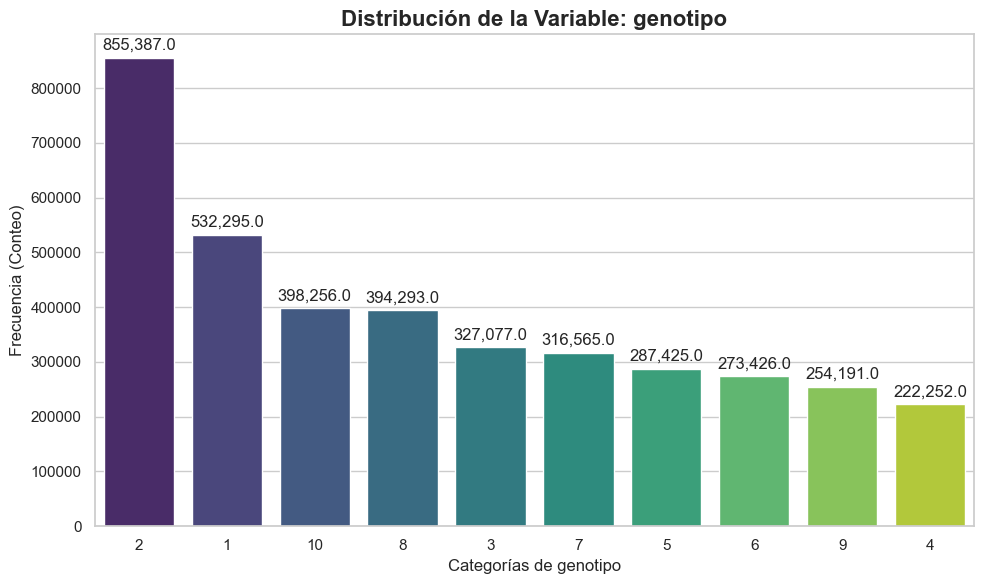

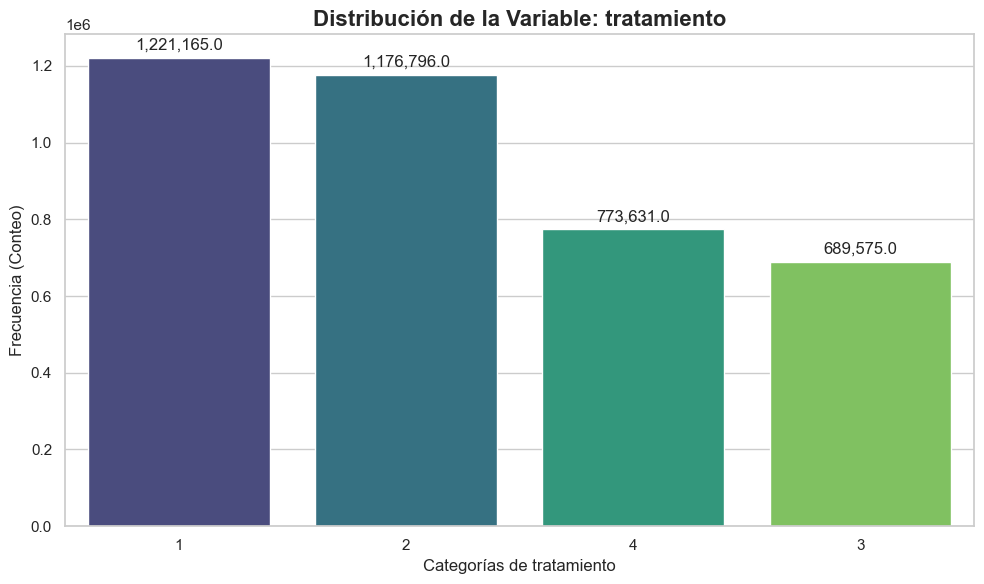

In [10]:
for col in columnas_categoricas:
    plt.figure(figsize=(10, 6))
    ax = sns.countplot(x=col, data=data, order=data[col].value_counts().index, palette='viridis')
    ax.set_title(f'Distribución de la Variable: {col}', fontsize=16, fontweight='bold')
    ax.set_xlabel(f'Categorías de {col}', fontsize=12)
    ax.set_ylabel('Frecuencia (Conteo)', fontsize=12)
    for p in ax.patches:
        ax.annotate(f'{p.get_height():,}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 9), textcoords='offset points')
    plt.tight_layout()
    plt.show()

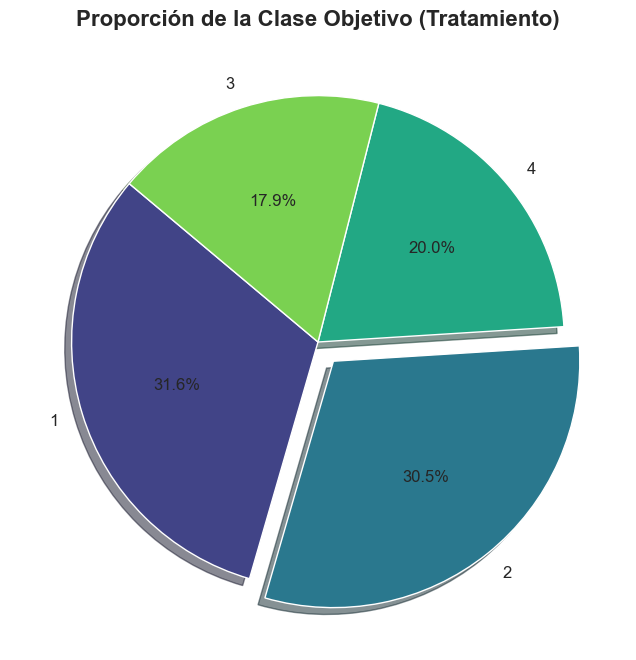

In [11]:
counts = data['tratamiento'].value_counts()
colors = sns.color_palette('viridis', len(counts))
explode = [0.1 if i == counts.idxmax() else 0 for i, _ in enumerate(counts)]

plt.figure(figsize=(8, 8))
plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=140,
        colors=colors, explode=explode, shadow=True, textprops={'fontsize': 12})
plt.title('Proporción de la Clase Objetivo (Tratamiento)', fontsize=16, fontweight='bold')
plt.ylabel('')
plt.show()

## 3.2. Distribución de bandas espectrales por tipo de característica

Se visualiza la distribución de los tres grupos de características espectrales (intensidad, media vecinal, desviación estándar vecinal) para evaluar si aportan información complementaria.

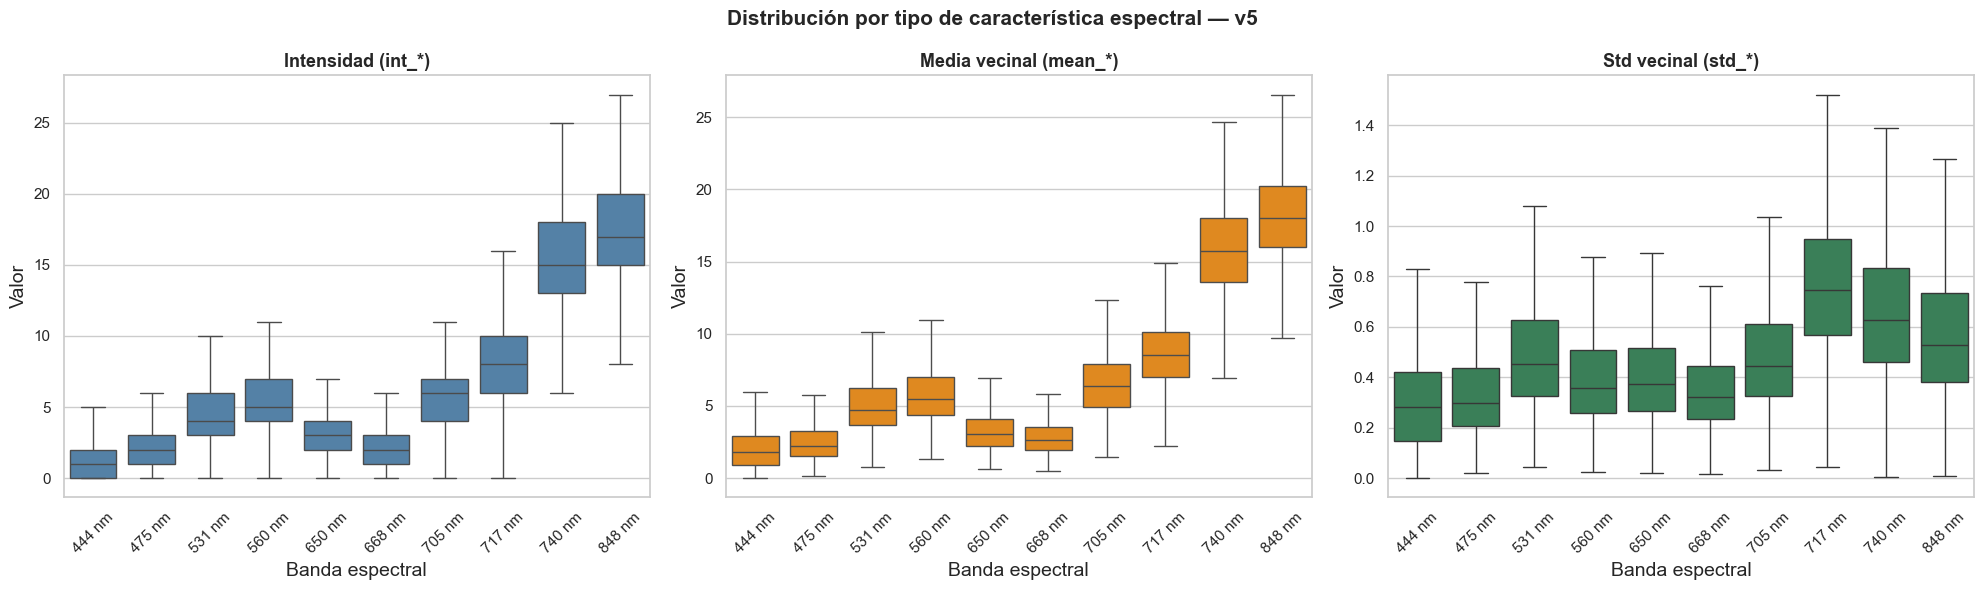

In [12]:
# Boxplot comparativo por tipo de característica (int vs mean vs std) para cada banda
# Muestra la longitud de onda como eje x y el valor como eje y

fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=False)

sample_n = min(30000, len(data))
sample_df = data.sample(n=sample_n, random_state=42)

grupos = [
    (int_cols,  "Intensidad (int_*)",       axes[0], "steelblue"),
    (mean_cols, "Media vecinal (mean_*)",    axes[1], "darkorange"),
    (std_cols,  "Std vecinal (std_*)",       axes[2], "seagreen"),
]

for cols, title, ax, color in grupos:
    melted = sample_df.melt(value_vars=cols, var_name="banda", value_name="valor")
    melted["nm"] = melted["banda"].str.extract(r"(\d+)").astype(int)
    melted = melted.sort_values("nm")
    melted["banda_label"] = melted["nm"].astype(str) + " nm"
    order = sorted(melted["banda_label"].unique(), key=lambda x: int(x.split()[0]))
    sns.boxplot(data=melted, x="banda_label", y="valor", order=order,
                ax=ax, color=color, showfliers=False)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel("Banda espectral")
    ax.set_ylabel("Valor")
    ax.tick_params(axis='x', rotation=45)

plt.suptitle("Distribución por tipo de característica espectral — v5", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

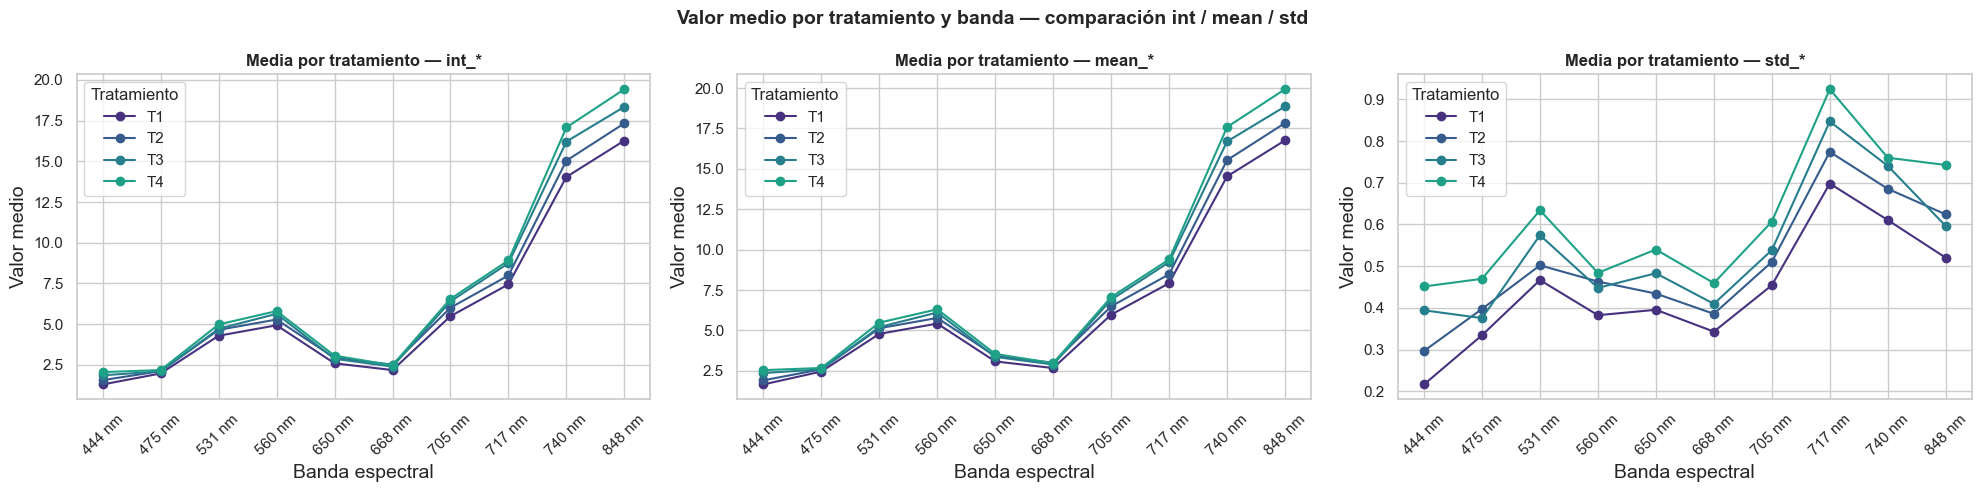

In [13]:
# Intensidad media por tratamiento para los tres tipos de característica
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

grupos = [
    (int_cols,  "int_*",  axes[0]),
    (mean_cols, "mean_*", axes[1]),
    (std_cols,  "std_*",  axes[2]),
]

for cols, prefix, ax in grupos:
    melted = sample_df.melt(
        id_vars=["tratamiento"], value_vars=cols,
        var_name="banda", value_name="valor"
    )
    melted["nm"] = melted["banda"].str.extract(r"(\d+)").astype(int)
    melted = melted.sort_values("nm")
    melted["banda_label"] = melted["nm"].astype(str) + " nm"
    order = sorted(melted["banda_label"].unique(), key=lambda x: int(x.split()[0]))
    mean_df = melted.groupby(["banda_label", "tratamiento"])["valor"].mean().reset_index()
    for t in sorted(mean_df["tratamiento"].unique()):
        sub = mean_df[mean_df["tratamiento"] == t].set_index("banda_label").loc[order, "valor"]
        ax.plot(order, sub.values, marker='o', label=f"T{t}")
    ax.set_title(f"Media por tratamiento — {prefix}", fontsize=12, fontweight='bold')
    ax.set_xlabel("Banda espectral")
    ax.set_ylabel("Valor medio")
    ax.legend(title="Tratamiento")
    ax.tick_params(axis='x', rotation=45)

plt.suptitle("Valor medio por tratamiento y banda — comparación int / mean / std", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 3.3. Análisis de Correlación y Reducción de Dimensionalidad

El dataset v5 tiene **33 características** (2 espaciales + 10 int + 10 mean + 10 std + genotipo). Antes de entrenar los modelos es necesario evaluar:

1. **Redundancia entre int_\* y mean_\***: La media de los 8 vecinos de un píxel suele ser muy similar al valor del píxel mismo cuando la imagen es suave; si la correlación es > 0.95 las columnas mean_\* no aportan información nueva.
2. **Aportación de std_\***: La desviación estándar vecinal captura heterogeneidad local (textura), que es una característica genuinamente distinta de la intensidad.
3. **Análisis de componentes principales (PCA)**: Para comprender cuánta varianza acumulada captura un número reducido de componentes.

A partir de este análisis se definirá el conjunto de características (`selected_feature_cols`) que se usará para el entrenamiento.

### 3.3.1. Matriz de correlación de características espectrales

Se calcula la correlación de Pearson entre las 30 variables espectrales agrupadas por tipo (int_* → mean_* → std_*). Las correlaciones altas dentro del bloque int/mean indican redundancia.

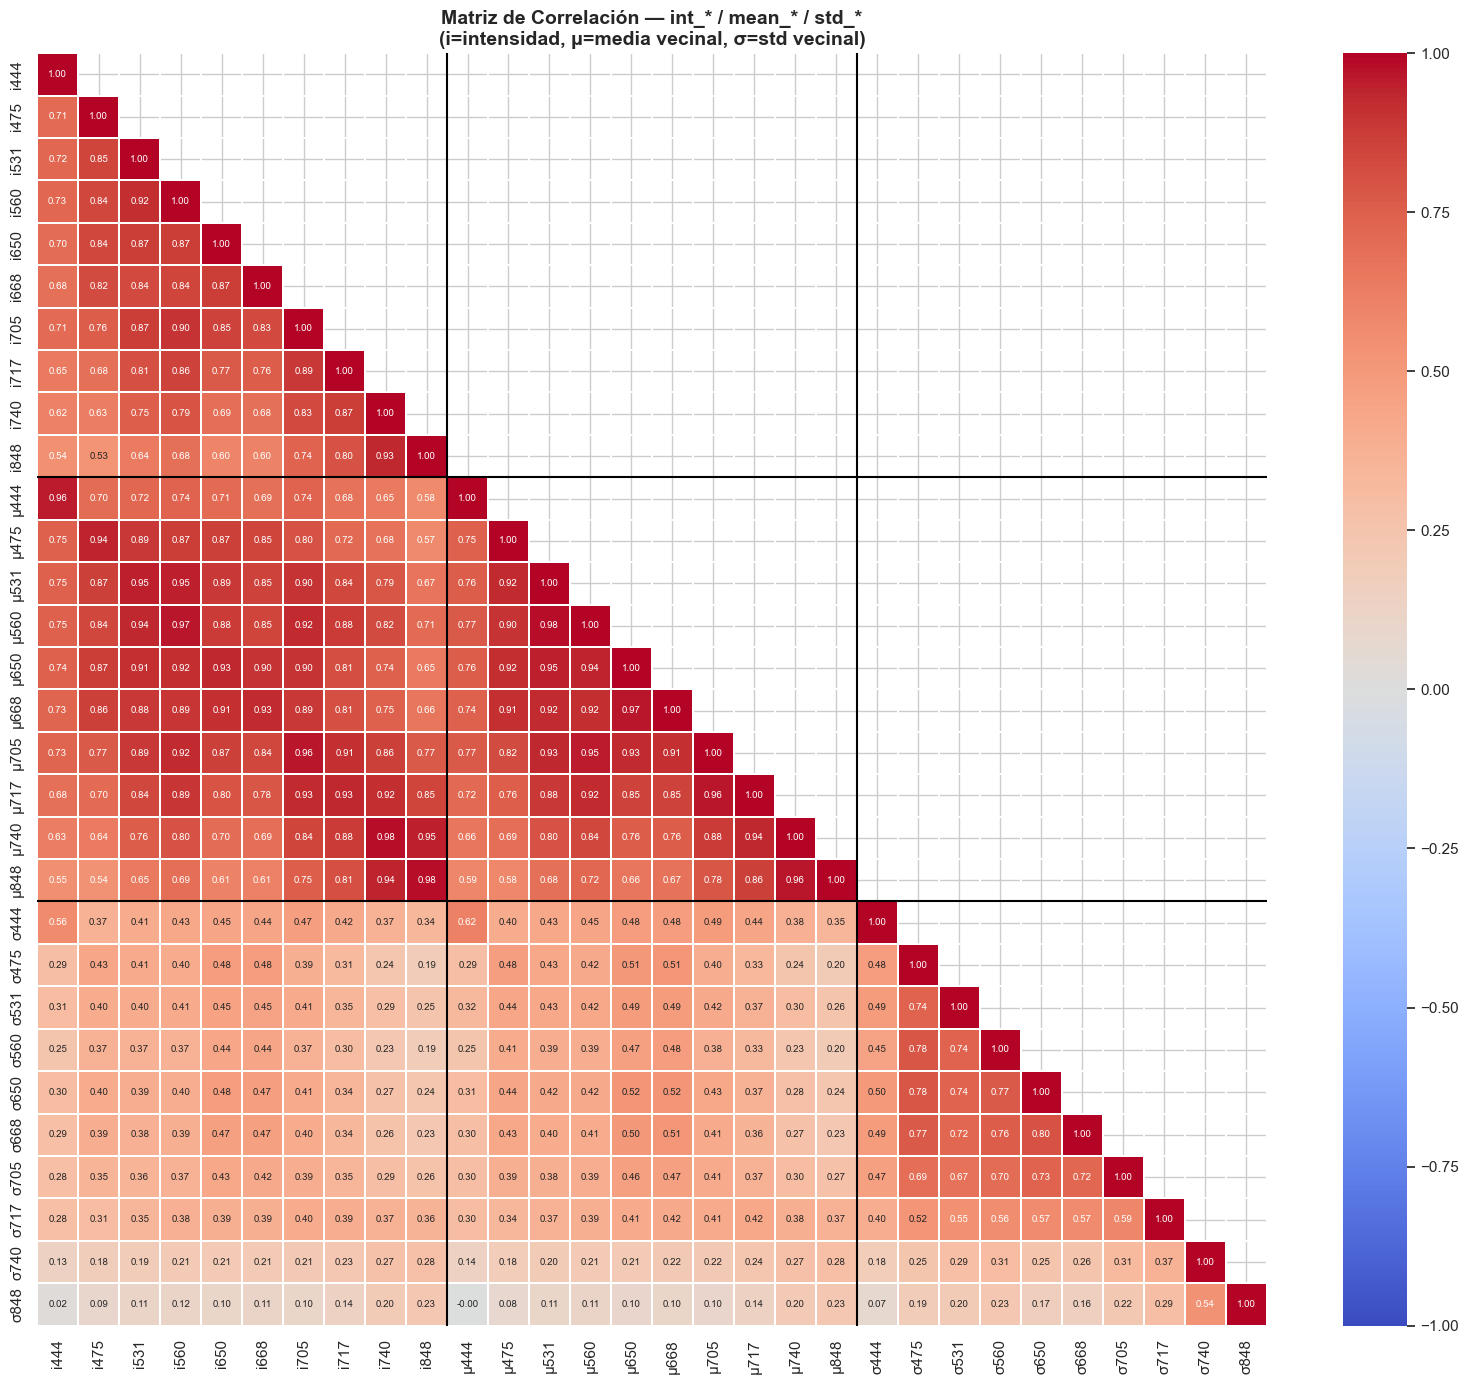

In [14]:
# Correlación de Pearson entre las 30 características espectrales (int + mean + std)
# Agrupadas en ese orden para visualizar claramente los bloques de correlación

ordered_spectral = int_cols + mean_cols + std_cols
corr_spectral = data[ordered_spectral].sample(n=min(50000, len(data)), random_state=42).corr()

# Etiquetas cortas (número de banda en nm)
short_labels = (
    [f"i{c.split('_')[1]}" for c in int_cols] +
    [f"μ{c.split('_')[1]}" for c in mean_cols] +
    [f"σ{c.split('_')[1]}" for c in std_cols]
)

fig, ax = plt.subplots(figsize=(16, 14))
mask = np.triu(np.ones_like(corr_spectral, dtype=bool), k=1)  # triángulo superior
sns.heatmap(
    corr_spectral,
    mask=mask,
    annot=True, fmt=".2f", annot_kws={"size": 7},
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    linewidths=0.3, linecolor='white',
    xticklabels=short_labels, yticklabels=short_labels,
    ax=ax,
)

# Líneas divisorias entre bloques int / mean / std
n = len(int_cols)
for pos in [n, 2*n]:
    ax.axhline(pos, color='black', linewidth=1.5)
    ax.axvline(pos, color='black', linewidth=1.5)

ax.set_title('Matriz de Correlación — int_* / mean_* / std_*\n(i=intensidad, μ=media vecinal, σ=std vecinal)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [15]:
# Correlación puntual int_nm <-> mean_nm para cada banda (diagonal del bloque int/mean)
print("Correlación puntual  int_<nm>  ↔  mean_<nm>  (misma longitud de onda):")
print("-" * 45)
for ic, mc in zip(int_cols, mean_cols):
    nm = ic.split("_")[1]
    r = data[[ic, mc]].corr().iloc[0, 1]
    marca = "⚠️ redundante" if abs(r) > 0.95 else "✅ complementario"
    print(f"  {ic:12s} ↔ {mc:13s}  r = {r:.4f}  {marca}")

Correlación puntual  int_<nm>  ↔  mean_<nm>  (misma longitud de onda):
---------------------------------------------
  int_444      ↔ mean_444       r = 0.9550  ⚠️ redundante
  int_475      ↔ mean_475       r = 0.9380  ✅ complementario
  int_531      ↔ mean_531       r = 0.9489  ✅ complementario
  int_560      ↔ mean_560       r = 0.9659  ⚠️ redundante
  int_650      ↔ mean_650       r = 0.9323  ✅ complementario
  int_668      ↔ mean_668       r = 0.9259  ✅ complementario
  int_705      ↔ mean_705       r = 0.9641  ⚠️ redundante
  int_717      ↔ mean_717       r = 0.9316  ✅ complementario
  int_740      ↔ mean_740       r = 0.9779  ⚠️ redundante
  int_848      ↔ mean_848       r = 0.9835  ⚠️ redundante


### 3.3.2. Importancia de características (Random Forest rápido)

Se entrena un `RandomForestClassifier` con una muestra del 10 % para obtener un ranking de importancia de características sin el coste computacional del entrenamiento completo. Esto permite confirmar si las columnas `std_*` y `mean_*` aportan discriminación real o son prescindibles.

RF importancia entrenado en 24.0s sobre 271,882 muestras (10%)


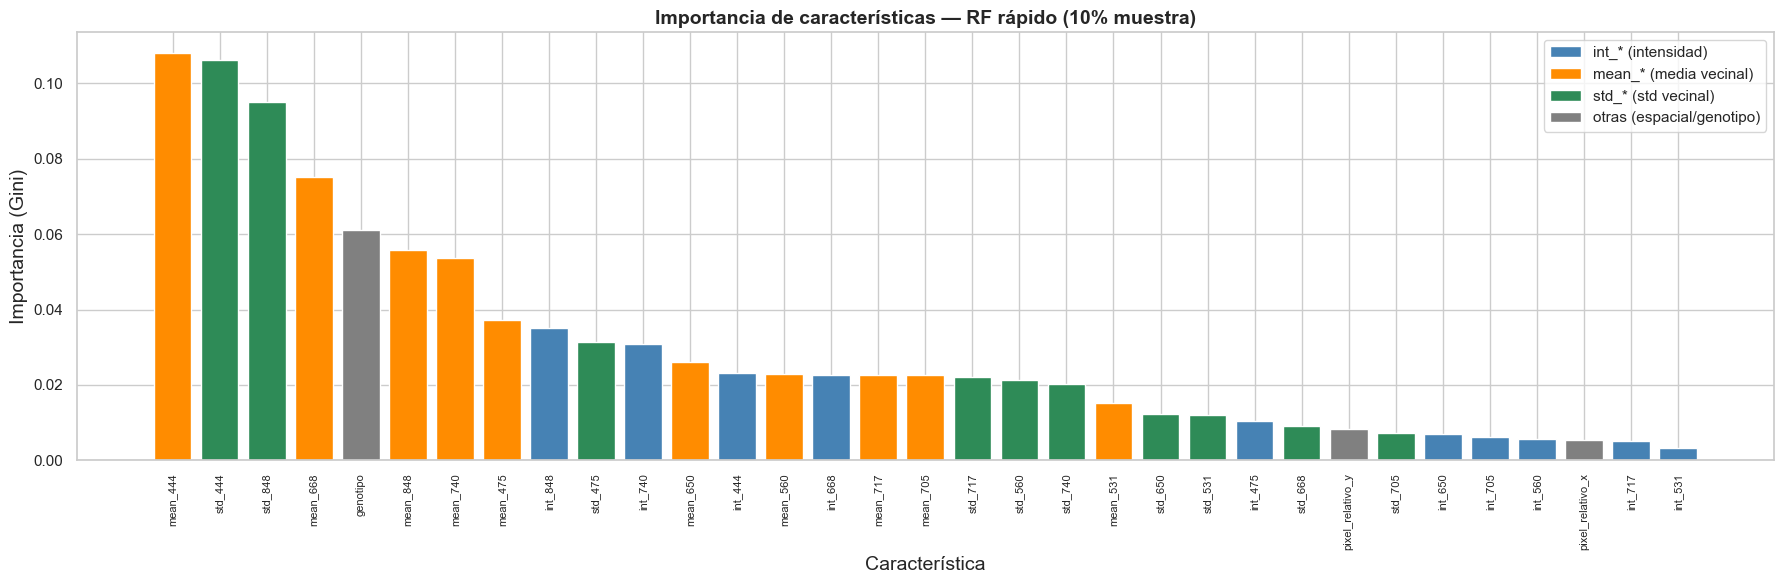


Top 15 características más importantes:


,importancia
mean_444,0.108157
std_444,0.106194
std_848,0.095050
mean_668,0.075296
genotipo,0.061043
mean_848,0.055872
mean_740,0.053679
mean_475,0.037305
int_848,0.034981
std_475,0.031276


In [16]:
FEATURE_IMPORTANCE_SAMPLE = 0.10
all_feat_cols = ["pixel_relativo_x", "pixel_relativo_y", "genotipo"] + spectral_cols

sample_size = int(len(data_train) * FEATURE_IMPORTANCE_SAMPLE)
fi_sample = data_train.sample(n=sample_size, random_state=42)

X_fi = fi_sample[all_feat_cols].values
y_fi = fi_sample["tratamiento"].values

rf_fi = RandomForestClassifier(n_estimators=100, max_depth=10, n_jobs=-1, random_state=42)
t0 = time.time()
rf_fi.fit(X_fi, y_fi)
print(f"RF importancia entrenado en {time.time() - t0:.1f}s sobre {sample_size:,} muestras ({FEATURE_IMPORTANCE_SAMPLE*100:.0f}%)")

importances = pd.Series(rf_fi.feature_importances_, index=all_feat_cols).sort_values(ascending=False)

# Colorear barras por tipo de característica
palette_map = {}
for c in all_feat_cols:
    if c.startswith("int_"):    palette_map[c] = "steelblue"
    elif c.startswith("mean_"): palette_map[c] = "darkorange"
    elif c.startswith("std_"):  palette_map[c] = "seagreen"
    else:                       palette_map[c] = "gray"

fig, ax = plt.subplots(figsize=(18, 6))
bars = ax.bar(importances.index, importances.values,
              color=[palette_map[c] for c in importances.index])
ax.set_title("Importancia de características — RF rápido (10% muestra)", fontsize=14, fontweight='bold')
ax.set_ylabel("Importancia (Gini)")
ax.set_xlabel("Característica")
plt.xticks(rotation=90, fontsize=8)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='steelblue',  label='int_* (intensidad)'),
    Patch(facecolor='darkorange', label='mean_* (media vecinal)'),
    Patch(facecolor='seagreen',   label='std_* (std vecinal)'),
    Patch(facecolor='gray',       label='otras (espacial/genotipo)'),
]
ax.legend(handles=legend_elements)
plt.tight_layout()
plt.show()

print("\nTop 15 características más importantes:")
display(importances.head(15).to_frame("importancia").style.background_gradient(cmap='YlOrRd'))

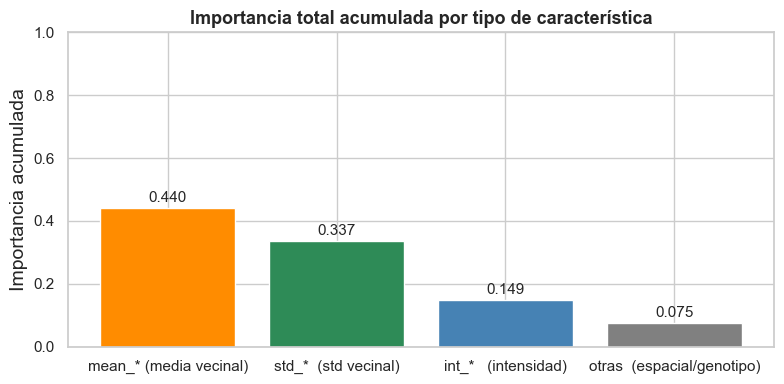

In [17]:
# Importancia acumulada por tipo de característica
imp_by_type = {
    "int_*   (intensidad)": importances[[c for c in importances.index if c.startswith("int_")]].sum(),
    "mean_* (media vecinal)": importances[[c for c in importances.index if c.startswith("mean_")]].sum(),
    "std_*  (std vecinal)": importances[[c for c in importances.index if c.startswith("std_")]].sum(),
    "otras  (espacial/genotipo)": importances[[c for c in importances.index
                                               if not c.startswith(("int_","mean_","std_"))]].sum(),
}

imp_type_df = pd.Series(imp_by_type).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
colors_type = ["steelblue", "darkorange", "seagreen", "gray"]
sorted_colors = [{"int_*   (intensidad)": "steelblue", "mean_* (media vecinal)": "darkorange",
                  "std_*  (std vecinal)": "seagreen", "otras  (espacial/genotipo)": "gray"}[k]
                 for k in imp_type_df.index]
ax.bar(imp_type_df.index, imp_type_df.values, color=sorted_colors)
ax.set_title("Importancia total acumulada por tipo de característica", fontsize=13, fontweight='bold')
ax.set_ylabel("Importancia acumulada")
ax.set_ylim(0, 1)
for i, (k, v) in enumerate(imp_type_df.items()):
    ax.text(i, v + 0.01, f"{v:.3f}", ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()

### 3.3.3. Análisis de Componentes Principales (PCA)

Se aplica PCA a las 30 características espectrales para estudiar cuántos componentes explican el 95% de la varianza total. Esto sirve tanto para cuantificar la redundancia como para evaluar si la compresión PCA puede ser una alternativa viable.

Componentes para 90% de varianza: 5 / 30
Componentes para 95% de varianza: 11 / 30
Componentes para 99% de varianza: 20 / 30


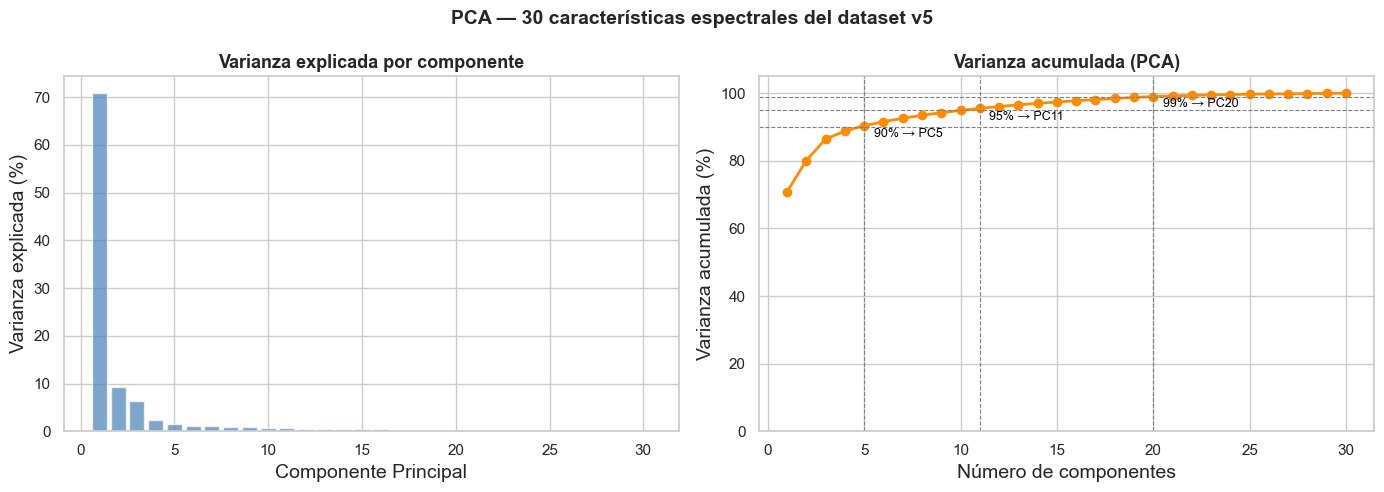

In [18]:
# PCA sobre las 30 características espectrales (escala previa con MinMaxScaler)
pca_sample = data[spectral_cols].sample(n=min(50000, len(data)), random_state=42)
scaler_pca = MinMaxScaler()
pca_scaled = scaler_pca.fit_transform(pca_sample)

pca_full = PCA(n_components=len(spectral_cols), random_state=42)
pca_full.fit(pca_scaled)

explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

# Número de componentes para 90%, 95%, 99%
thresholds = [0.90, 0.95, 0.99]
for t in thresholds:
    n_comp = np.argmax(cumulative >= t) + 1
    print(f"Componentes para {t*100:.0f}% de varianza: {n_comp} / {len(spectral_cols)}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Varianza por componente
axes[0].bar(range(1, len(explained)+1), explained * 100, color='steelblue', alpha=0.7)
axes[0].set_xlabel("Componente Principal")
axes[0].set_ylabel("Varianza explicada (%)")
axes[0].set_title("Varianza explicada por componente", fontsize=13, fontweight='bold')

# Varianza acumulada
axes[1].plot(range(1, len(cumulative)+1), cumulative * 100, marker='o', color='darkorange', linewidth=2)
for t in thresholds:
    n_comp = np.argmax(cumulative >= t) + 1
    axes[1].axhline(t*100, linestyle='--', color='gray', linewidth=0.8)
    axes[1].axvline(n_comp, linestyle='--', color='gray', linewidth=0.8)
    axes[1].annotate(f"{t*100:.0f}% → PC{n_comp}", xy=(n_comp, t*100),
                     xytext=(n_comp+0.5, t*100-3), fontsize=9, color='black')
axes[1].set_xlabel("Número de componentes")
axes[1].set_ylabel("Varianza acumulada (%)")
axes[1].set_title("Varianza acumulada (PCA)", fontsize=13, fontweight='bold')
axes[1].set_ylim(0, 105)

plt.suptitle("PCA — 30 características espectrales del dataset v5", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.3.4. Decisión: selección del conjunto de características

Basándonos en los análisis previos se definen las estrategias espectrales y se elige la más adecuada:

| Estrategia | Características espectrales | Dimensiones | Razonamiento |
|---|---|---|---|
| **A — Completo** | int + mean + std | 30 | Línea base con todos los datos espectrales |
| **B — Sin mean_\*** | int + std | 20 | Si `corr(int, mean) > 0.95`: elimina redundancia |

> **Nota:** Las características `pixel_relativo_x/y` y `genotipo` son **excluidas** en ambas estrategias. Los experimentos 3.4.2 y 3.4.3 mostraron que ninguna aporta mejora significativa al F1 (diferencia < 1 %), y su exclusión mejora la parsimonia y la generalizabilidad a genotipos no vistos.

**Criterio de decisión espectral:**
- Si las correlaciones `int_nm ↔ mean_nm` son > 0.90 → usar **Estrategia B** (elimina redundancia, mantiene textura)
- Si las correlaciones son < 0.90 (mean aporta contexto suavizado distinto) → usar **Estrategia A**

La variable `selected_feature_cols` definida abajo recoge la estrategia elegida.


In [19]:
# Evaluar correlación promedio int <-> mean para decidir estrategia
corrs_int_mean = []
for ic, mc in zip(int_cols, mean_cols):
    r = data[[ic, mc]].sample(n=min(50000, len(data)), random_state=42).corr().iloc[0, 1]
    corrs_int_mean.append(abs(r))

mean_corr = np.mean(corrs_int_mean)
high_redundancy = mean_corr > 0.90  # umbral para considerar mean_* redundante

print(f"Correlación media |int_nm ↔ mean_nm|: {mean_corr:.4f}")
print(f"Umbral de redundancia (> 0.90): {'SÍ → Estrategia B (sin mean_*)' if high_redundancy else 'NO → Estrategia A (todas las características)'}")

# ─── DEFINICIÓN DE CARACTERÍSTICAS SELECCIONADAS ────────────────────────────
# pixel_relativo_x/y y genotipo excluidos: experimentos 3.4.2 y 3.4.3
# confirmaron que no aportan mejora significativa (diferencia < 1 %)
STRATEGY = "B" if high_redundancy else "A"

if STRATEGY == "A":
    selected_feature_cols = int_cols + mean_cols + std_cols
elif STRATEGY == "B":
    # Elimina mean_* (redundante con int_*), conserva la información de textura std_*
    selected_feature_cols = int_cols + std_cols

print(f"\nEstrategia seleccionada: {STRATEGY}")
print(f"Número de características: {len(selected_feature_cols)}")
print(f"Características: {selected_feature_cols}")


Correlación media |int_nm ↔ mean_nm|: 0.9525
Umbral de redundancia (> 0.90): SÍ → Estrategia B (sin mean_*)

Estrategia seleccionada: B
Número de características: 20
Características: ['int_444', 'int_475', 'int_531', 'int_560', 'int_650', 'int_668', 'int_705', 'int_717', 'int_740', 'int_848', 'std_444', 'std_475', 'std_531', 'std_560', 'std_650', 'std_668', 'std_705', 'std_717', 'std_740', 'std_848']


## 3.4. Análisis del efecto genotipo y características espaciales

Antes de entrenar los modelos finales es necesario verificar si las features `genotipo` y `pixel_relativo_x/y` ayudan a discriminar el tratamiento o si introducen **confounding** / ruido.

Se realizan tres experimentos:

1. **PCA diagnóstico** sobre las 10 bandas `int_*`: se grafican los primeros 2 componentes coloreando por `tratamiento` y por `genotipo` en paneles separados. Si los clusters se forman por genotipo, el espacio espectral está dominado por el efecto varietal.
2. **RF rápido con/sin genotipo**: se compara el F1 ponderado en validación cruzada `GroupKFold` entrenando con `int_*` vs `int_* + genotipo`. Una diferencia < 1 % indica que el genotipo no aporta valor discriminativo real.
3. **RF rápido con/sin características espaciales**: mismo esquema, comparando `int_*` vs `int_* + pixel_relativo_x + pixel_relativo_y`. Permite determinar si la posición del píxel dentro del objeto contribuye a discriminar deficiencias.


In [ ]:
### 3.4.1 PCA diagnóstico — ¿separa tratamiento o genotipo?
PCA_DIAG_N = min(30000, len(data))
diag_sample = data.sample(n=PCA_DIAG_N, random_state=42)

scaler_diag = MinMaxScaler()
X_pca_diag  = scaler_diag.fit_transform(diag_sample[int_cols])
pca_diag    = PCA(n_components=2, random_state=42)
coords_diag = pca_diag.fit_transform(X_pca_diag)

pc1_var = pca_diag.explained_variance_ratio_[0] * 100
pc2_var = pca_diag.explained_variance_ratio_[1] * 100

trat_vals = diag_sample["tratamiento"].values
geno_vals = diag_sample["genotipo"].values

pal_trat = sns.color_palette("viridis", len(np.unique(trat_vals)))
pal_geno = sns.color_palette("tab10",   len(np.unique(geno_vals)))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel izquierdo: coloreado por tratamiento
for i, t in enumerate(sorted(np.unique(trat_vals))):
    mask = trat_vals == t
    axes[0].scatter(coords_diag[mask, 0], coords_diag[mask, 1],
                    s=1, alpha=0.25, color=pal_trat[i], label=f"T{t}")
axes[0].set_title(f"PCA — coloreado por Tratamiento\n(PC1={pc1_var:.1f}%,  PC2={pc2_var:.1f}%)",
                  fontsize=13, fontweight="bold")
axes[0].set_xlabel(f"PC1 ({pc1_var:.1f}%)")
axes[0].set_ylabel(f"PC2 ({pc2_var:.1f}%)")
axes[0].legend(markerscale=7, title="Tratamiento", fontsize=9)
axes[0].grid(True, alpha=0.3, linestyle="--")

# Panel derecho: coloreado por genotipo
for i, g in enumerate(sorted(np.unique(geno_vals))):
    mask = geno_vals == g
    axes[1].scatter(coords_diag[mask, 0], coords_diag[mask, 1],
                    s=1, alpha=0.25, color=pal_geno[i % len(pal_geno)], label=f"G{g}")
axes[1].set_title(f"PCA — coloreado por Genotipo\n(PC1={pc1_var:.1f}%,  PC2={pc2_var:.1f}%)",
                  fontsize=13, fontweight="bold")
axes[1].set_xlabel(f"PC1 ({pc1_var:.1f}%)")
axes[1].set_ylabel(f"PC2 ({pc2_var:.1f}%)")
axes[1].legend(markerscale=7, title="Genotipo", fontsize=9, ncol=2)
axes[1].grid(True, alpha=0.3, linestyle="--")

plt.suptitle("Diagnóstico PCA sobre bandas int_*\n¿qué factor estructura el espacio espectral?",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

print(f"\nVarianza explicada: PC1={pc1_var:.1f}%, PC2={pc2_var:.1f}%, acumulada={pc1_var+pc2_var:.1f}%")
print("\nInterpretación:")
print("  • Clusters por TRATAMIENTO → el modelo puede aprender a distinguir deficiencias de fósforo.")
print("  • Clusters por GENOTIPO    → el espacio espectral está dominado por variación varietal (confounding).")


Experimento RF (10% muestra = 271,882 píxeles, GroupKFold-3):
-------------------------------------------------------
  Sin genotipo  (int_*): F1=0.4379  (±0.0272)
  Con genotipo  (int_* + genotipo): F1=0.4136  (±0.0154)

Diferencia (con − sin): -0.0243
  → El genotipo REDUCE el F1. Introduce confounding — considerar eliminarlo del modelo.


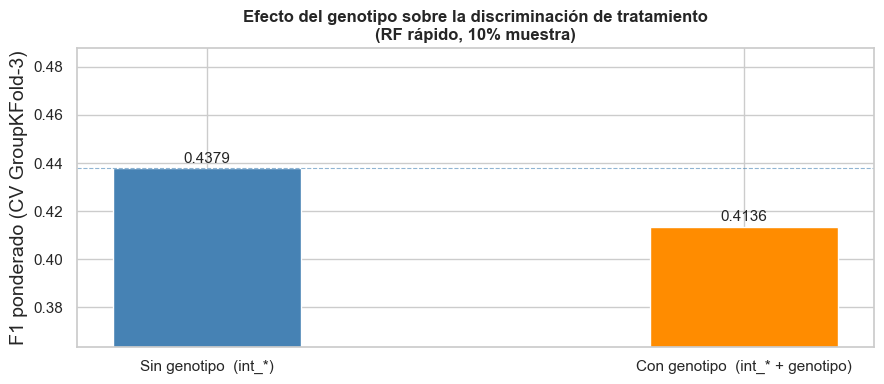


Variable GENOTIPO_UTIL = False  (usado en decisión de features si se desea)


In [22]:
### 3.4.2 RF rápido — con vs sin genotipo
from sklearn.metrics import f1_score as _f1

RF_GENO_SAMPLE = 0.10
n_rf_geno = int(len(data_train) * RF_GENO_SAMPLE)
rf_geno_df = data_train.sample(n=n_rf_geno, random_state=42)

groups_geno = rf_geno_df["object_id"]
y_geno      = rf_geno_df["tratamiento"]

feats_sin = int_cols                   # solo reflectancia espectral
feats_con = int_cols + ["genotipo"]    # reflectancia + identidad varietal

X_sin = MinMaxScaler().fit_transform(rf_geno_df[feats_sin])
X_con = MinMaxScaler().fit_transform(rf_geno_df[feats_con])

gkf_geno = GroupKFold(n_splits=3)
rf_geno_clf = RandomForestClassifier(n_estimators=100, max_depth=10, n_jobs=-1, random_state=42)

print(f"Experimento RF (10% muestra = {n_rf_geno:,} píxeles, GroupKFold-3):")
print("-" * 55)

results_geno = {}
for label, X_exp in [("Sin genotipo  (int_*)", X_sin),
                      ("Con genotipo  (int_* + genotipo)", X_con)]:
    scores = []
    for tr_idx, val_idx in gkf_geno.split(X_exp, y_geno, groups=groups_geno):
        rf_geno_clf.fit(X_exp[tr_idx], y_geno.iloc[tr_idx])
        y_pred_val = rf_geno_clf.predict(X_exp[val_idx])
        scores.append(_f1(y_geno.iloc[val_idx], y_pred_val, average="weighted"))
    mu, sd = np.mean(scores), np.std(scores)
    results_geno[label] = mu
    print(f"  {label}: F1={mu:.4f}  (±{sd:.4f})")

diff = results_geno["Con genotipo  (int_* + genotipo)"] - results_geno["Sin genotipo  (int_*)"]
print(f"\nDiferencia (con − sin): {diff:+.4f}")
if abs(diff) < 0.01:
    conclusion = "El genotipo NO aporta mejora significativa (<1%). Se puede mantener o quitar sin impacto."
elif diff > 0:
    conclusion = "El genotipo MEJORA el F1. Aporta discriminación útil — mantener en el modelo."
else:
    conclusion = "El genotipo REDUCE el F1. Introduce confounding — considerar eliminarlo del modelo."
print(f"  → {conclusion}")

# Gráfico comparativo
fig, ax = plt.subplots(figsize=(9, 4))
labels_bar = list(results_geno.keys())
values_bar = list(results_geno.values())
colors_bar = ["steelblue", "darkorange"]
bars_geno  = ax.bar(labels_bar, values_bar, color=colors_bar, width=0.35)
y_lim_min  = max(0, min(values_bar) - 0.05)
y_lim_max  = min(1, max(values_bar) + 0.05)
ax.set_ylim(y_lim_min, y_lim_max)
ax.set_ylabel("F1 ponderado (CV GroupKFold-3)")
ax.set_title("Efecto del genotipo sobre la discriminación de tratamiento\n(RF rápido, 10% muestra)",
             fontsize=12, fontweight="bold")
for bar, val in zip(bars_geno, values_bar):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.001,
            f"{val:.4f}", ha="center", va="bottom", fontsize=11)
ax.axhline(results_geno["Sin genotipo  (int_*)"], color="steelblue",
           linestyle="--", linewidth=0.8, alpha=0.6)
plt.tight_layout()
plt.show()

# Guardar conclusión para referencia posterior
GENOTIPO_UTIL = diff > 0.01
print(f"\nVariable GENOTIPO_UTIL = {GENOTIPO_UTIL}  (usado en decisión de features si se desea)")


Experimento RF (10% muestra = 271,882 píxeles, GroupKFold-3):
-----------------------------------------------------------------
  Sin espaciales  (int_*): F1=0.4379  (±0.0272)
  Con espaciales  (int_* + x/y relativo): F1=0.4284  (±0.0256)

Diferencia (con − sin): -0.0095
  → Las características espaciales NO aportan mejora significativa (<1%). Se pueden omitir sin impacto.


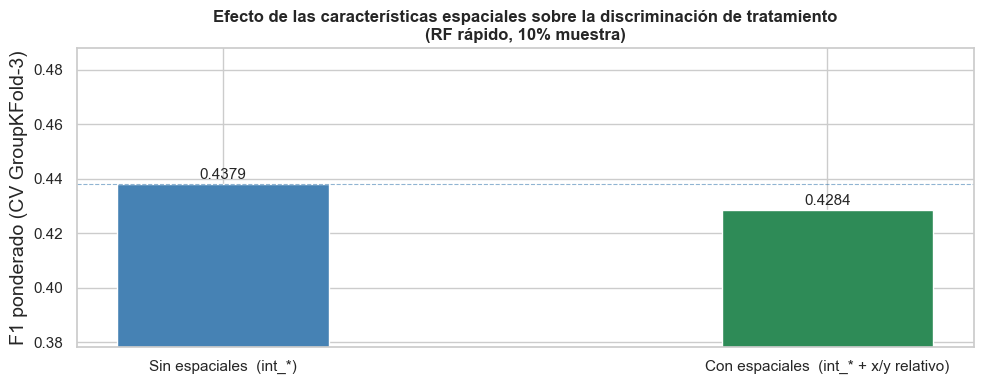


Variable ESPACIAL_UTIL = False  (usado en decisión de features si se desea)


In [23]:
### 3.4.3 RF rápido — con vs sin características espaciales (pixel_relativo_x/y)

spatial_cols = ["pixel_relativo_x", "pixel_relativo_y"]

RF_ESP_SAMPLE = 0.10
n_rf_esp = int(len(data_train) * RF_ESP_SAMPLE)
rf_esp_df = data_train.sample(n=n_rf_esp, random_state=42)

groups_esp = rf_esp_df["object_id"]
y_esp      = rf_esp_df["tratamiento"]

feats_esp_sin = int_cols                       # solo reflectancia espectral
feats_esp_con = int_cols + spatial_cols        # reflectancia + posición relativa

X_esp_sin = MinMaxScaler().fit_transform(rf_esp_df[feats_esp_sin])
X_esp_con = MinMaxScaler().fit_transform(rf_esp_df[feats_esp_con])

gkf_esp     = GroupKFold(n_splits=3)
rf_esp_clf  = RandomForestClassifier(n_estimators=100, max_depth=10, n_jobs=-1, random_state=42)

print(f"Experimento RF (10% muestra = {n_rf_esp:,} píxeles, GroupKFold-3):")
print("-" * 65)

results_esp = {}
for label, X_exp in [("Sin espaciales  (int_*)",               X_esp_sin),
                      ("Con espaciales  (int_* + x/y relativo)", X_esp_con)]:
    scores = []
    for tr_idx, val_idx in gkf_esp.split(X_exp, y_esp, groups=groups_esp):
        rf_esp_clf.fit(X_exp[tr_idx], y_esp.iloc[tr_idx])
        y_pred_val = rf_esp_clf.predict(X_exp[val_idx])
        scores.append(_f1(y_esp.iloc[val_idx], y_pred_val, average="weighted"))
    mu, sd = np.mean(scores), np.std(scores)
    results_esp[label] = mu
    print(f"  {label}: F1={mu:.4f}  (±{sd:.4f})")

diff_esp = results_esp["Con espaciales  (int_* + x/y relativo)"] - results_esp["Sin espaciales  (int_*)"]
print(f"\nDiferencia (con − sin): {diff_esp:+.4f}")
if abs(diff_esp) < 0.01:
    conclusion_esp = "Las características espaciales NO aportan mejora significativa (<1%). Se pueden omitir sin impacto."
elif diff_esp > 0:
    conclusion_esp = "Las características espaciales MEJORAN el F1. La posición del píxel aporta discriminación útil."
else:
    conclusion_esp = "Las características espaciales REDUCEN el F1. Introducen ruido — considerar eliminarlas."
print(f"  → {conclusion_esp}")

# Gráfico comparativo
fig, ax = plt.subplots(figsize=(10, 4))
labels_bar_esp = list(results_esp.keys())
values_bar_esp = list(results_esp.values())
colors_bar_esp = ["steelblue", "seagreen"]
bars_esp = ax.bar(labels_bar_esp, values_bar_esp, color=colors_bar_esp, width=0.35)
y_lim_min_esp = max(0, min(values_bar_esp) - 0.05)
y_lim_max_esp = min(1, max(values_bar_esp) + 0.05)
ax.set_ylim(y_lim_min_esp, y_lim_max_esp)
ax.set_ylabel("F1 ponderado (CV GroupKFold-3)")
ax.set_title("Efecto de las características espaciales sobre la discriminación de tratamiento\n(RF rápido, 10% muestra)",
             fontsize=12, fontweight="bold")
for bar, val in zip(bars_esp, values_bar_esp):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.001,
            f"{val:.4f}", ha="center", va="bottom", fontsize=11)
ax.axhline(results_esp["Sin espaciales  (int_*)"], color="steelblue",
           linestyle="--", linewidth=0.8, alpha=0.6)
plt.tight_layout()
plt.show()

ESPACIAL_UTIL = diff_esp > 0.01
print(f"\nVariable ESPACIAL_UTIL = {ESPACIAL_UTIL}  (usado en decisión de features si se desea)")


# 4. Preprocesamiento de Datos

## 4.1. División de datos en conjuntos de entrenamiento y prueba

Se usan los splits por objeto predefinidos en el dataset v5 (estratificado por tratamiento, 70/30, semilla 42). No se realiza división adicional para evitar fuga de información entre píxeles del mismo objeto.

In [24]:
y_train = data_train['tratamiento'].copy()
y_test  = data_test['tratamiento'].copy()

missing_train = [c for c in selected_feature_cols if c not in data_train.columns]
missing_test  = [c for c in selected_feature_cols if c not in data_test.columns]
if missing_train or missing_test:
    raise ValueError(f"Faltan columnas. train={missing_train}, test={missing_test}")

X_train = data_train[selected_feature_cols].copy()
X_test  = data_test[selected_feature_cols].copy()

excluded = [c for c in data_train.columns if c not in selected_feature_cols + ['tratamiento']]
print(f"Características usadas ({len(selected_feature_cols)}): {selected_feature_cols}")
print(f"Columnas excluidas del modelo: {excluded}")
print(f"\nTrain: {X_train.shape}  |  Test: {X_test.shape}")

Características usadas (20): ['int_444', 'int_475', 'int_531', 'int_560', 'int_650', 'int_668', 'int_705', 'int_717', 'int_740', 'int_848', 'std_444', 'std_475', 'std_531', 'std_560', 'std_650', 'std_668', 'std_705', 'std_717', 'std_740', 'std_848']
Columnas excluidas del modelo: ['pixel_relativo_x', 'pixel_relativo_y', 'genotipo', 'object_id', 'split', 'mean_444', 'mean_475', 'mean_531', 'mean_560', 'mean_650', 'mean_668', 'mean_705', 'mean_717', 'mean_740', 'mean_848']

Train: (2718828, 20)  |  Test: (1142339, 20)


## 4.2. Normalización de características

MinMaxScaler escala todas las variables al rango [0, 1]. El ajuste se realiza **solo sobre el conjunto de entrenamiento** para evitar fuga de información del conjunto de prueba.

In [25]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"X_train escalado: {X_train_scaled.shape}")
print(f"X_test  escalado: {X_test_scaled.shape}")

X_train escalado: (2718828, 20)
X_test  escalado: (1142339, 20)


## 4.3. Codificación de tratamiento (XGBoost)

XGBoost requiere etiquetas enteras desde 0. LabelEncoder convierte [1, 2, 3, 4] → [0, 1, 2, 3].

In [8]:
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded  = le.transform(y_test)
print(f"Clases originales: {le.classes_}  →  codificadas: {np.unique(y_train_encoded)}")

Clases originales: [1 2 3 4]  →  codificadas: [0 1 2 3]


## 4.4. Persistencia de datos procesados

In [27]:
np.savez(
    "results/data/train_data_maiz_v5.npz",
    X_train_scaled=X_train_scaled,
    X_test_scaled=X_test_scaled,
    y_train=y_train,
    y_test=y_test,
    y_train_encoded=y_train_encoded,
    y_test_encoded=y_test_encoded,
    feature_cols=np.array(selected_feature_cols),
    strategy=np.array([STRATEGY]),
)
print("✅ Datos guardados en results/data/train_data_maiz_v5.npz")

✅ Datos guardados en results/data/train_data_maiz_v5.npz


## 4.5. Carga de datos preprocesados

In [3]:
train_data = np.load("results/data/train_data_maiz_v5.npz", allow_pickle=True)

X_train_scaled   = train_data["X_train_scaled"]
X_test_scaled    = train_data["X_test_scaled"]
y_train          = train_data["y_train"]
y_test           = train_data["y_test"]
y_train_encoded  = train_data["y_train_encoded"]
y_test_encoded   = train_data["y_test_encoded"]
selected_feature_cols = list(train_data["feature_cols"])
STRATEGY         = str(train_data["strategy"][0])

print(f"Datos cargados — Estrategia: {STRATEGY}")
print(f"X_train: {X_train_scaled.shape}  |  X_test: {X_test_scaled.shape}")

Datos cargados — Estrategia: B
X_train: (2718828, 20)  |  X_test: (1142339, 20)


# 5. Entrenamiento de Modelos de Aprendizaje Automático

Se entrenan los mismos cuatro clasificadores que en la versión v4 para mantener comparabilidad. El conjunto de características ahora incluye las características de textura (std_* de vecindad) que distinguen este dataset.

**Modelos:**
1. **K-Nearest Neighbors (KNN)**
2. **Random Forest (RF)**
3. **XGBoost**
4. **Multi-Layer Perceptron (MLP)**

In [29]:
os.makedirs("models/maiz/hyperparameter_tuning", exist_ok=True)
os.makedirs("models/maiz/best", exist_ok=True)

def medir_tiempo_entrenamiento(func):
    def wrapper(*args, nombre_modelo=None, **kwargs):
        modelo = args[0] if args else kwargs.get("estimator")
        etiqueta = nombre_modelo or (modelo.__class__.__name__ if modelo is not None else func.__name__)
        inicio = time.time()
        resultado = func(*args, **kwargs)
        fin = time.time()
        print(f"⏱️ {etiqueta} entrenado en {fin - inicio:.2f}s")
        return resultado
    return wrapper


@medir_tiempo_entrenamiento
def train_model(estimator):
    estimator.fit(X_train_scaled, y_train)
    return estimator


def medir_tiempo_prediccion(func):
    def wrapper(estimator, type: str):
        etiqueta = estimator.__class__.__name__
        inicio = time.time()
        resultado = func(estimator, type)
        fin = time.time()
        print(f"⏱️ {etiqueta} ({type}) predicho en {fin - inicio:.2f}s")
        return resultado
    return wrapper


@medir_tiempo_prediccion
def make_prediction(estimator, type: str):
    if type == "test":
        return estimator.predict(X_test_scaled)
    elif type == "train":
        return estimator.predict(X_train_scaled)
    else:
        raise ValueError("type debe ser 'train' o 'test'")

## 5.1. K-Nearest Neighbors (KNN)

In [30]:
knn = KNeighborsClassifier(n_jobs=-1)
knn_classifier = train_model(knn)
joblib.dump(knn_classifier, "models/maiz/modelo_knn_v5.pkl")

⏱️ KNeighborsClassifier entrenado en 0.47s


['models/maiz/modelo_knn_v5.pkl']

## 5.2. Random Forest (RF)

In [31]:
rfc = RandomForestClassifier(n_jobs=-1, random_state=12)
rf_classifier = train_model(rfc)
joblib.dump(rf_classifier, "models/maiz/modelo_rfc_v5.pkl")

⏱️ RandomForestClassifier entrenado en 432.58s


['models/maiz/modelo_rfc_v5.pkl']

## 5.3. XGBoost

In [32]:
xgbc = xgb.XGBClassifier(random_state=42)
inicio = time.time()
xgb_classifier = xgbc.fit(X_train_scaled, y_train_encoded)
print(f"⏱️ XGBClassifier entrenado en {time.time() - inicio:.2f}s")
joblib.dump(xgb_classifier, "models/maiz/modelo_xgb_v5.pkl")

⏱️ XGBClassifier entrenado en 52.96s


['models/maiz/modelo_xgb_v5.pkl']

## 5.4. Multi-Layer Perceptron (MLP)

In [33]:
mlp = MLPClassifier()
mlp_classifier = train_model(mlp)
joblib.dump(mlp_classifier, "models/maiz/modelo_mlp_v5.pkl")

⏱️ MLPClassifier entrenado en 2251.54s


['models/maiz/modelo_mlp_v5.pkl']

## 5.5. Carga de modelos previamente entrenados

In [ ]:
knn_classifier = joblib.load("models/maiz/modelo_knn_v5.pkl")
rf_classifier  = joblib.load("models/maiz/modelo_rfc_v5.pkl")
xgb_classifier = joblib.load("models/maiz/modelo_xgb_v5.pkl")
mlp_classifier = joblib.load("models/maiz/modelo_mlp_v5.pkl")

# 6. Generación de Predicciones

## 6.1. KNN

In [34]:
knn_prediction_train = make_prediction(knn_classifier, "train")
knn_prediction_test  = make_prediction(knn_classifier, "test")
joblib.dump(knn_prediction_test,  "results/predictions/maiz/test/predicciones_knn_test_v5.pkl")
joblib.dump(knn_prediction_train, "results/predictions/maiz/train/predicciones_knn_train_v5.pkl")

⏱️ KNeighborsClassifier (train) predicho en 7763.20s
⏱️ KNeighborsClassifier (test) predicho en 3207.62s


['results/predictions/maiz/train/predicciones_knn_train_v5.pkl']

In [ ]:
knn_prediction_test  = joblib.load("results/predictions/maiz/test/predicciones_knn_test_v5.pkl")
knn_prediction_train = joblib.load("results/predictions/maiz/train/predicciones_knn_train_v5.pkl")

## 6.2. Random Forest

In [35]:
rf_prediction_train = make_prediction(rf_classifier, "train")
rf_prediction_test  = make_prediction(rf_classifier, "test")
joblib.dump(rf_prediction_test,  "results/predictions/maiz/test/predicciones_rf_test_v5.pkl")
joblib.dump(rf_prediction_train, "results/predictions/maiz/train/predicciones_rf_train_v5.pkl")

⏱️ RandomForestClassifier (train) predicho en 64.24s
⏱️ RandomForestClassifier (test) predicho en 36.86s


['results/predictions/maiz/train/predicciones_rf_train_v5.pkl']

In [ ]:
rf_prediction_test  = joblib.load("results/predictions/maiz/test/predicciones_rf_test_v5.pkl")
rf_prediction_train = joblib.load("results/predictions/maiz/train/predicciones_rf_train_v5.pkl")

## 6.3. XGBoost

In [36]:
xgb_prediction_train = make_prediction(xgb_classifier, "train")
xgb_prediction_test  = make_prediction(xgb_classifier, "test")
joblib.dump(xgb_prediction_test,  "results/predictions/maiz/test/predicciones_xgb_test_v5.pkl")
joblib.dump(xgb_prediction_train, "results/predictions/maiz/train/predicciones_xgb_train_v5.pkl")

⏱️ XGBClassifier (train) predicho en 4.81s
⏱️ XGBClassifier (test) predicho en 1.68s


['results/predictions/maiz/train/predicciones_xgb_train_v5.pkl']

In [ ]:
xgb_prediction_test  = joblib.load("results/predictions/maiz/test/predicciones_xgb_test_v5.pkl")
xgb_prediction_train = joblib.load("results/predictions/maiz/train/predicciones_xgb_train_v5.pkl")

## 6.4. MLP

In [37]:
mlp_prediction_train = make_prediction(mlp_classifier, "train")
mlp_prediction_test  = make_prediction(mlp_classifier, "test")
joblib.dump(mlp_prediction_test,  "results/predictions/maiz/test/predicciones_mlp_test_v5.pkl")
joblib.dump(mlp_prediction_train, "results/predictions/maiz/train/predicciones_mlp_train_v5.pkl")

⏱️ MLPClassifier (train) predicho en 10.50s
⏱️ MLPClassifier (test) predicho en 4.58s


['results/predictions/maiz/train/predicciones_mlp_train_v5.pkl']

In [ ]:
mlp_prediction_test  = joblib.load("results/predictions/maiz/test/predicciones_mlp_test_v5.pkl")
mlp_prediction_train = joblib.load("results/predictions/maiz/train/predicciones_mlp_train_v5.pkl")

# 7. Evaluación del Modelo

In [38]:
classifiers_names    = ["knn", "rfc", "xgb", "mlp"]
predictions_train    = [knn_prediction_train, rf_prediction_train, xgb_prediction_train, mlp_prediction_train]
predictions_test     = [knn_prediction_test,  rf_prediction_test,  xgb_prediction_test,  mlp_prediction_test]

classifier_display_names = {
    "knn": "K-Nearest Neighbors",
    "rfc": "Random Forest",
    "xgb": "XGBoost",
    "mlp": "Perceptrón Multicapa"
}
tratamiento_labels = ['T1', 'T2', 'T3', 'T4']

## 7.1. Entrenamiento — matrices de confusión

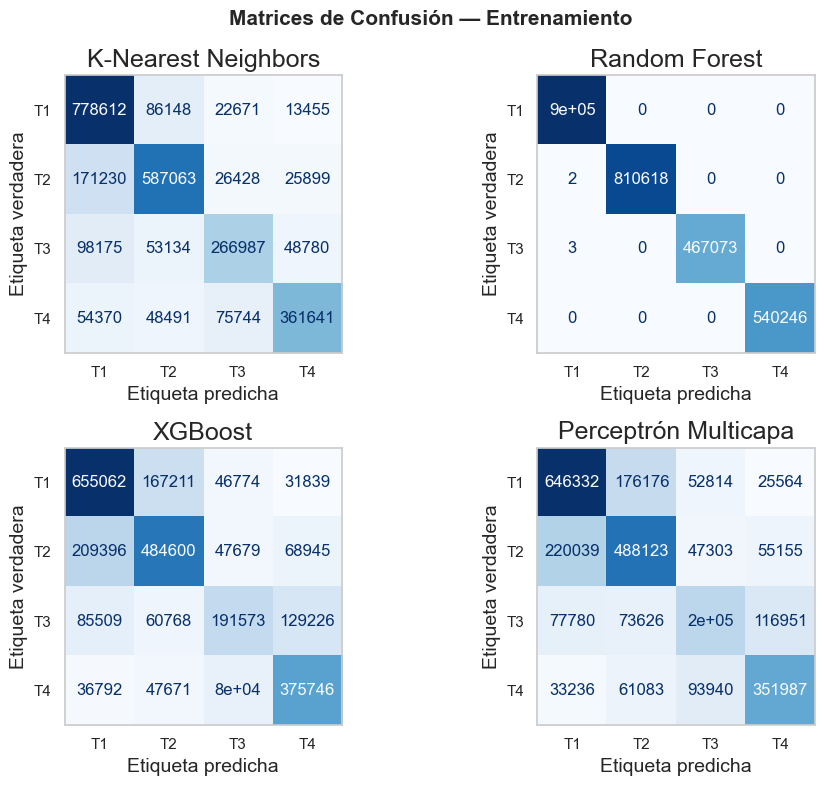

In [39]:
def build_cm(y_true, y_pred):
    return confusion_matrix(y_true, y_pred, labels=None, normalize=None)

# Calcular matrices de confusión (XGB usa etiquetas codificadas)
cmxs_train = []
cmxs_test  = []
for name, pred_tr, pred_te in zip(classifiers_names, predictions_train, predictions_test):
    if name == 'xgb':
        cmxs_train.append(build_cm(y_train_encoded, pred_tr))
        cmxs_test.append(build_cm(y_test_encoded, pred_te))
    else:
        cmxs_train.append(build_cm(y_train, pred_tr))
        cmxs_test.append(build_cm(y_test, pred_te))

num_models = len(classifiers_names)
ncols = 2
nrows = math.ceil(num_models / ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()

for i, (cm, name) in enumerate(zip(cmxs_train, classifiers_names)):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=tratamiento_labels)
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(classifier_display_names.get(name, name))
    axes[i].grid(False)
    axes[i].set_xlabel('Etiqueta predicha')
    axes[i].set_ylabel('Etiqueta verdadera')

for j in range(num_models, len(axes)):
    axes[j].axis('off')

plt.suptitle("Matrices de Confusión — Entrenamiento", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [40]:
def compute_metrics(y_true, y_pred, model_name):
    report = classification_report(y_true, y_pred, output_dict=True)
    return {
        'Modelo': model_name,
        'Accuracy': report['accuracy'],
        'Precision (Ponderada)': report['weighted avg']['precision'],
        'Recall (Ponderado)': report['weighted avg']['recall'],
        'F1-Score (Ponderado)': report['weighted avg']['f1-score'],
        'Kappa Score': cohen_kappa_score(y_true, y_pred),
    }

results_train = []
for preds, name in zip(predictions_train, classifiers_names):
    yt = y_train_encoded if name == 'xgb' else y_train
    results_train.append(compute_metrics(yt, preds, classifier_display_names.get(name, name)))

df_train = pd.DataFrame(results_train).set_index('Modelo')
print("Métricas — Entrenamiento")
display(df_train.style.background_gradient(cmap='summer_r', axis=0))

Métricas — Entrenamiento


,Accuracy,Precision (Ponderada),Recall (Ponderado),F1-Score (Ponderado),Kappa Score
Modelo,,,,,
K-Nearest Neighbors,0.733516,0.736755,0.733516,0.730342,0.631444
Random Forest,0.999998,0.999998,0.999998,0.999998,0.999997
XGBoost,0.627837,0.623176,0.627837,0.623235,0.489467
Perceptrón Multicapa,0.619812,0.615423,0.619812,0.616622,0.477959


## 7.2. Testing — matrices de confusión y métricas

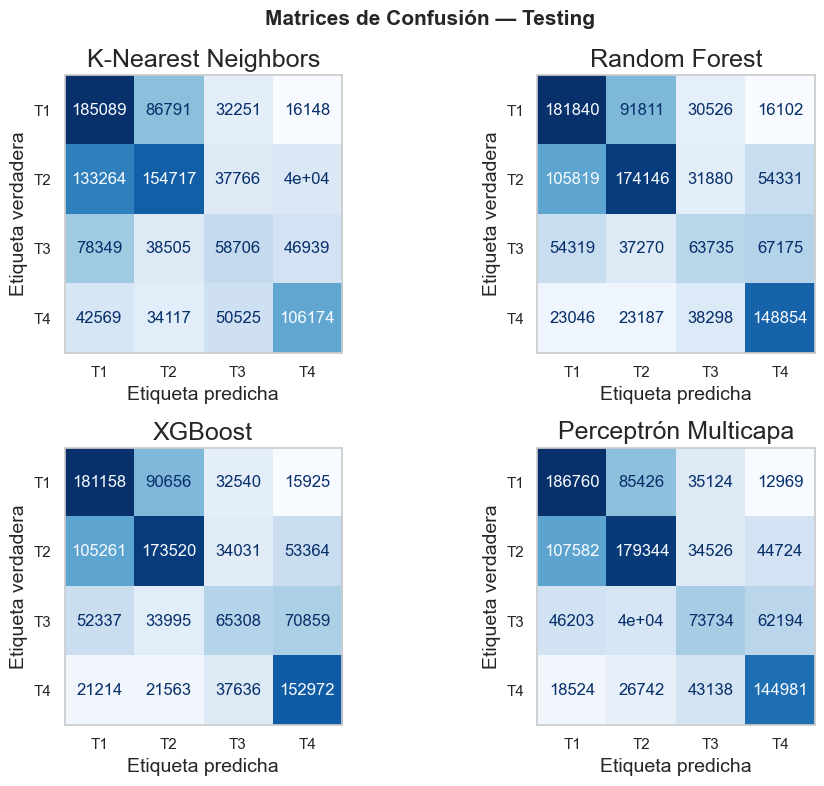

In [41]:
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()

for i, (cm, name) in enumerate(zip(cmxs_test, classifiers_names)):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=tratamiento_labels)
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(classifier_display_names.get(name, name))
    axes[i].grid(False)
    axes[i].set_xlabel('Etiqueta predicha')
    axes[i].set_ylabel('Etiqueta verdadera')

for j in range(num_models, len(axes)):
    axes[j].axis('off')

plt.suptitle("Matrices de Confusión — Testing", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [42]:
results_test = []
for preds, name in zip(predictions_test, classifiers_names):
    yt = y_test_encoded if name == 'xgb' else y_test
    results_test.append(compute_metrics(yt, preds, classifier_display_names.get(name, name)))

df_test = pd.DataFrame(results_test).set_index('Modelo')
print("Métricas — Testing")
display(df_test.style.background_gradient(cmap='summer_r', axis=0))

Métricas — Testing


,Accuracy,Precision (Ponderada),Recall (Ponderado),F1-Score (Ponderado),Kappa Score
Modelo,,,,,
K-Nearest Neighbors,0.441801,0.443253,0.441801,0.437282,0.241550
Random Forest,0.497729,0.492342,0.497729,0.491155,0.320837
XGBoost,0.501566,0.496723,0.501566,0.495131,0.326989
Perceptrón Multicapa,0.511949,0.507875,0.511949,0.507985,0.340087


## 7.3. Evaluación por objeto (voto mayoritario) en testing

Los modelos predicen a nivel de píxel. Para evaluar a nivel de planta/hoja se agrega mediante voto mayoritario por `object_id`.

In [43]:
if 'object_id' not in data_test.columns:
    raise ValueError("La columna 'object_id' no está en data_test.")

obj_base = pd.DataFrame({
    'object_id': data_test['object_id'].reset_index(drop=True),
    'y_true': (y_test.reset_index(drop=True) if isinstance(y_test, pd.Series) else pd.Series(y_test)),
})

y_true_obj = (
    obj_base.groupby('object_id')['y_true']
    .agg(lambda s: s.mode().iloc[0])
    .rename('y_true_obj')
)

object_results = []
for name, y_pred_px in zip(classifiers_names, predictions_test):
    pred_series = pd.Series(y_pred_px).reset_index(drop=True)
    if name == 'xgb' and 'le' in globals():
        try:
            pred_series = pd.Series(le.inverse_transform(pred_series.astype(int)))
        except Exception:
            pass

    pred_df = obj_base[['object_id']].copy()
    pred_df['y_pred'] = pred_series.values
    y_pred_obj = (
        pred_df.groupby('object_id')['y_pred']
        .agg(lambda s: s.mode().iloc[0])
        .rename('y_pred_obj')
    )
    comp = pd.concat([y_true_obj, y_pred_obj], axis=1).dropna()
    obj_acc = (comp['y_true_obj'] == comp['y_pred_obj']).mean()
    object_results.append({
        'Modelo': classifier_display_names.get(name, name),
        'Objetos evaluados': len(comp),
        'Accuracy (objeto - voto mayoritario)': obj_acc
    })

obj_df = pd.DataFrame(object_results).set_index('Modelo').sort_values(
    'Accuracy (objeto - voto mayoritario)', ascending=False
)
print("Métricas de testing a nivel de objeto (voto mayoritario) — v5:")
display(obj_df.style.background_gradient(cmap='summer_r', axis=0))

Métricas de testing a nivel de objeto (voto mayoritario) — v5:


,Objetos evaluados,Accuracy (objeto - voto mayoritario)
Modelo,,
Perceptrón Multicapa,172,0.656977
Random Forest,172,0.639535
XGBoost,172,0.639535
K-Nearest Neighbors,172,0.610465


# 8. Selección de Hiperparámetros

Búsqueda de hiperparámetros mediante `RandomizedSearchCV` con `GroupKFold` para respetar la separación por objeto. El ajuste se realiza sobre una muestra del 60 % del conjunto de entrenamiento para reducir el coste computacional; el modelo final se reentrena con todos los datos.

In [4]:
def make_rand_grid_search(estimator, param_dist):
    gkf = GroupKFold(n_splits=3)
    return RandomizedSearchCV(
        estimator=estimator,
        param_distributions=param_dist,
        n_iter=20,
        cv=gkf,
        scoring="f1_weighted",
        random_state=12,
        n_jobs=-1,
        refit=True,
    )


def save_model_and_params(model, model_name, best_params, score, stage="hyperparameter_tuning"):
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    model_info = {
        'model': model,
        'best_params': best_params,
        'best_score': score,
        'timestamp': timestamp,
        'model_name': model_name,
        'stage': stage,
        'dataset_version': 'v5',
        'strategy': STRATEGY,
    }
    save_path = f'models/maiz/{stage}/{model_name}_{timestamp}_v5.pkl'
    joblib.dump(model_info, save_path, compress=3)
    print(f"✅ {model_name} guardado en: {save_path}")
    return save_path


def load_model_info(filepath):
    model_info = joblib.load(filepath)
    print(f"✅ {model_info['model_name']} cargado — Score: {model_info['best_score']:.4f}  ({model_info['timestamp']})")
    return model_info


def load_latest_model(model_name, stage="best"):
    path = f'models/maiz/{stage}'
    if not os.path.exists(path):
        print(f"❌ Directorio {path} no existe"); return None
    files = [f for f in os.listdir(path) if f.startswith(model_name) and f.endswith('_v5.pkl')]
    if not files:
        print(f"No se encontraron modelos v5 de tipo {model_name} en {stage}"); return None
    files.sort(reverse=True)
    return load_model_info(os.path.join(path, files[0]))

## 8.1. Selección de muestra para búsqueda

In [9]:
HYPERPARAMETER_SAMPLE_SIZE = 0.15
RANDOM_STATE = 42

print(f"Dataset de entrenamiento completo: {X_train_scaled.shape[0]:,} muestras")

X_train_sample, _, y_train_sample, _, groups_sample, _ = train_test_split(
    X_train_scaled,
    y_train,
    data_train['object_id'],
    test_size=1 - HYPERPARAMETER_SAMPLE_SIZE,
    stratify=y_train,
    random_state=RANDOM_STATE,
)

y_train_sample_encoded = le.transform(y_train_sample)

print(f"Muestra para hiperparámetros: {X_train_sample.shape[0]:,} ({HYPERPARAMETER_SAMPLE_SIZE*100:.0f}%)")
print(f"\nDistribución de clases en muestra:")
print(pd.Series(y_train_sample).value_counts().sort_index())

Dataset de entrenamiento completo: 2,718,828 muestras
Muestra para hiperparámetros: 407,824 (15%)

Distribución de clases en muestra:
1    135133
2    121593
3     70061
4     81037
Name: count, dtype: int64


## 8.2. KNN — Búsqueda de hiperparámetros

In [46]:
knn_param_grid = {
    'n_neighbors': [15, 30, 50, 100],
    'weights': ['uniform', 'distance'],
    'p': [1, 2],
}

try:
    t0 = time.time()
    knn_search = make_rand_grid_search(KNeighborsClassifier(n_jobs=-1), knn_param_grid)
    knn_search.fit(X_train_sample, y_train_sample, groups=groups_sample)
    print(f"⏱️ Búsqueda KNN: {time.time()-t0:.1f}s  |  Best F1: {knn_search.best_score_:.4f}")
    print(f"Mejores parámetros: {knn_search.best_params_}")
    save_model_and_params(knn_search, "KNN", knn_search.best_params_, knn_search.best_score_, "hyperparameter_tuning")
except Exception as e:
    print(f"❌ Error: {e}"); raise

⏱️ Búsqueda KNN: 12718.2s  |  Best F1: 0.5171
Mejores parámetros: {'weights': 'distance', 'p': 1, 'n_neighbors': 50}
✅ KNN guardado en: models/maiz/hyperparameter_tuning/KNN_20260422_042938_v5.pkl


In [ ]:
knn_final = KNeighborsClassifier(n_jobs=-1, **knn_search.best_params_)
t0 = time.time()
knn_final.fit(X_train_scaled, y_train)
print(f"⏱️ KNN final entrenado en {time.time()-t0:.1f}s")
save_model_and_params(knn_final, "KNN_final", knn_search.best_params_, knn_search.best_score_, "best")

knn_y_train_pred = knn_final.predict(X_train_scaled)
knn_y_test_pred  = knn_final.predict(X_test_scaled)
joblib.dump(knn_y_test_pred,  "results/predictions/maiz/test/best_predicciones_knn_test_v5.pkl")
joblib.dump(knn_y_train_pred, "results/predictions/maiz/train/best_predicciones_knn_train_v5.pkl")

print("\nTesting — KNN final:")
print(classification_report(y_test, knn_y_test_pred))

⏱️ KNN final entrenado en 1.6s
✅ KNN_final guardado en: models/maiz/best/KNN_final_20260422_042943_v5.pkl

Testing — KNN final:
              precision    recall  f1-score   support

           1       0.44      0.60      0.51    320279
           2       0.55      0.43      0.48    366176
           3       0.36      0.24      0.29    222499
           4       0.52      0.59      0.55    233385

    accuracy                           0.47   1142339
   macro avg       0.47      0.47      0.46   1142339
weighted avg       0.47      0.47      0.47   1142339



## 8.3. Random Forest — Búsqueda de hiperparámetros

In [10]:
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, 15],
    'min_samples_split': [20, 50, 100],
    'min_samples_leaf': [10, 20, 50],
    'max_features': ['sqrt', 'log2'],
}

try:
    t0 = time.time()
    rf_search = make_rand_grid_search(RandomForestClassifier(n_jobs=-1, random_state=12), rf_param_grid)
    rf_search.fit(X_train_sample, y_train_sample, groups=groups_sample)
    print(f"⏱️ Búsqueda RF: {time.time()-t0:.1f}s  |  Best F1: {rf_search.best_score_:.4f}")
    print(f"Mejores parámetros: {rf_search.best_params_}")
    save_model_and_params(rf_search, "RandomForest", rf_search.best_params_, rf_search.best_score_, "hyperparameter_tuning")
except Exception as e:
    print(f"❌ Error: {e}"); raise

⏱️ Búsqueda RF: 1635.1s  |  Best F1: 0.5144
Mejores parámetros: {'n_estimators': 100, 'min_samples_split': 50, 'min_samples_leaf': 10, 'max_features': 'log2', 'max_depth': 15}
✅ RandomForest guardado en: models/maiz/hyperparameter_tuning/RandomForest_20260427_055411_v5.pkl


In [11]:
rf_final = RandomForestClassifier(n_jobs=-1, random_state=12, **rf_search.best_params_)
t0 = time.time()
rf_final.fit(X_train_scaled, y_train)
print(f"⏱️ RF final entrenado en {time.time()-t0:.1f}s")
save_model_and_params(rf_final, "RandomForest_final", rf_search.best_params_, rf_search.best_score_, "best")

rf_y_train_pred = rf_final.predict(X_train_scaled)
rf_y_test_pred  = rf_final.predict(X_test_scaled)
joblib.dump(rf_y_test_pred,  "results/predictions/maiz/test/best_predicciones_rf_test_v5.pkl")
joblib.dump(rf_y_train_pred, "results/predictions/maiz/train/best_predicciones_rf_train_v5.pkl")

print("\nTesting — RF final:")
print(classification_report(y_test, rf_y_test_pred))

⏱️ RF final entrenado en 376.7s
✅ RandomForest_final guardado en: models/maiz/best/RandomForest_final_20260427_060040_v5.pkl

Testing — RF final:
              precision    recall  f1-score   support

           1       0.48      0.56      0.52    320279
           2       0.52      0.48      0.50    366176
           3       0.41      0.22      0.29    222499
           4       0.50      0.66      0.57    233385

    accuracy                           0.49   1142339
   macro avg       0.48      0.48      0.47   1142339
weighted avg       0.48      0.49      0.48   1142339



## 8.4. XGBoost — Búsqueda de hiperparámetros

In [7]:
xgb_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1, 0.3],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'min_child_weight': [1, 5, 10],
}

try:
    t0 = time.time()
    xgb_search = make_rand_grid_search(xgb.XGBClassifier(random_state=42), xgb_param_grid)
    xgb_search.fit(X_train_sample, y_train_sample_encoded, groups=groups_sample)
    print(f"⏱️ Búsqueda XGB: {time.time()-t0:.1f}s  |  Best F1: {xgb_search.best_score_:.4f}")
    print(f"Mejores parámetros: {xgb_search.best_params_}")
    save_model_and_params(xgb_search, "XGBoost", xgb_search.best_params_, xgb_search.best_score_, "hyperparameter_tuning")
except Exception as e:
    print(f"❌ Error: {e}"); raise

⏱️ Búsqueda XGB: 618.0s  |  Best F1: 0.5476
Mejores parámetros: {'subsample': 1.0, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.3, 'colsample_bytree': 1.0}
✅ XGBoost guardado en: models/maiz/hyperparameter_tuning/XGBoost_20260426_190843_v5.pkl


In [8]:
xgb_final = xgb.XGBClassifier(random_state=42, **xgb_search.best_params_)
t0 = time.time()
xgb_final.fit(X_train_scaled, y_train_encoded)
print(f"⏱️ XGB final entrenado en {time.time()-t0:.1f}s")
save_model_and_params(xgb_final, "XGBoost_final", xgb_search.best_params_, xgb_search.best_score_, "best")

xgb_y_train_pred = xgb_final.predict(X_train_scaled)
xgb_y_test_pred  = xgb_final.predict(X_test_scaled)
joblib.dump(xgb_y_test_pred,  "results/predictions/maiz/test/best_predicciones_xgb_test_v5.pkl")
joblib.dump(xgb_y_train_pred, "results/predictions/maiz/train/best_predicciones_xgb_train_v5.pkl")

print("\nTesting — XGB final:")
print(classification_report(y_test_encoded, xgb_y_test_pred))

⏱️ XGB final entrenado en 155.9s
✅ XGBoost_final guardado en: models/maiz/best/XGBoost_final_20260426_195549_v5.pkl

Testing — XGB final:
              precision    recall  f1-score   support

           0       0.51      0.56      0.53    320279
           1       0.55      0.48      0.51    366176
           2       0.39      0.31      0.34    222499
           3       0.53      0.65      0.58    233385

    accuracy                           0.51   1142339
   macro avg       0.49      0.50      0.49   1142339
weighted avg       0.50      0.51      0.50   1142339



## 8.5. MLP — Búsqueda de hiperparámetros

In [10]:
mlp_param_grid = {
    'hidden_layer_sizes': [(64,), (128,), (64, 32), (128, 64), (128, 64, 32)],
    'activation': ['relu', 'tanh'],
    'alpha': [1e-4, 1e-3, 1e-2],
    'learning_rate_init': [1e-3, 5e-4, 1e-4],
    'max_iter': [200],
}

try:
    t0 = time.time()
    mlp_search = make_rand_grid_search(MLPClassifier(random_state=42), mlp_param_grid)
    mlp_search.fit(X_train_sample, y_train_sample, groups=groups_sample)
    print(f"⏱️ Búsqueda MLP: {time.time()-t0:.1f}s  |  Best F1: {mlp_search.best_score_:.4f}")
    print(f"Mejores parámetros: {mlp_search.best_params_}")
    save_model_and_params(mlp_search, "MLP", mlp_search.best_params_, mlp_search.best_score_, "hyperparameter_tuning")
except Exception as e:
    print(f"❌ Error: {e}"); raise

⏱️ Búsqueda MLP: 38198.4s  |  Best F1: 0.5565
Mejores parámetros: {'max_iter': 200, 'learning_rate_init': 0.0001, 'hidden_layer_sizes': (128, 64, 32), 'alpha': 0.0001, 'activation': 'relu'}
✅ MLP guardado en: models/maiz/hyperparameter_tuning/MLP_20260427_190334_v5.pkl


In [ ]:
mlp_final = MLPClassifier(random_state=42, **mlp_search.best_params_)
t0 = time.time()
mlp_final.fit(X_train_scaled, y_train)
print(f"⏱️ MLP final entrenado en {time.time()-t0:.1f}s")
save_model_and_params(mlp_final, "MLP_final", mlp_search.best_params_, mlp_search.best_score_, "best")

mlp_y_train_pred = mlp_final.predict(X_train_scaled)
mlp_y_test_pred  = mlp_final.predict(X_test_scaled)
joblib.dump(mlp_y_test_pred,  "results/predictions/maiz/test/best_predicciones_mlp_test_v5.pkl")
joblib.dump(mlp_y_train_pred, "results/predictions/maiz/train/best_predicciones_mlp_train_v5.pkl")

print("\nTesting — MLP final:")
print(classification_report(y_test, mlp_y_test_pred))

## 8.6. Comparativa final de modelos optimizados

In [ ]:
# Cargar predicciones de modelos optimizados
# knn_y_test_pred  = joblib.load("results/predictions/maiz/test/best_predicciones_knn_test_v5.pkl")
# knn_y_train_pred = joblib.load("results/predictions/maiz/train/best_predicciones_knn_train_v5.pkl")
# rf_y_test_pred   = joblib.load("results/predictions/maiz/test/best_predicciones_rf_test_v5.pkl")
# rf_y_train_pred  = joblib.load("results/predictions/maiz/train/best_predicciones_rf_train_v5.pkl")
# xgb_y_test_pred  = joblib.load("results/predictions/maiz/test/best_predicciones_xgb_test_v5.pkl")
# xgb_y_train_pred = joblib.load("results/predictions/maiz/train/best_predicciones_xgb_train_v5.pkl")
# mlp_y_test_pred  = joblib.load("results/predictions/maiz/test/best_predicciones_mlp_test_v5.pkl")
# mlp_y_train_pred = joblib.load("results/predictions/maiz/train/best_predicciones_mlp_train_v5.pkl")

final_preds_test  = [knn_y_test_pred,  rf_y_test_pred,  xgb_y_test_pred,  mlp_y_test_pred]
final_preds_train = [knn_y_train_pred, rf_y_train_pred, xgb_y_train_pred, mlp_y_train_pred]

final_results = []
for name, pt, pte in zip(classifiers_names, final_preds_train, final_preds_test):
    yt_tr = y_train_encoded if name == 'xgb' else y_train
    yt_te = y_test_encoded  if name == 'xgb' else y_test
    r_tr = compute_metrics(yt_tr, pt,  classifier_display_names.get(name, name))
    r_te = compute_metrics(yt_te, pte, classifier_display_names.get(name, name))
    final_results.append({
        'Modelo': r_te['Modelo'],
        'Train Accuracy': r_tr['Accuracy'],
        'Test Accuracy':  r_te['Accuracy'],
        'Test F1 (Ponderado)': r_te['F1-Score (Ponderado)'],
        'Test Kappa': r_te['Kappa Score'],
    })

final_df = pd.DataFrame(final_results).set_index('Modelo').sort_values('Test F1 (Ponderado)', ascending=False)
print("Comparativa final — modelos optimizados (dataset v5):")
display(final_df.style.background_gradient(cmap='summer_r', axis=0))

In [ ]:
# Gráfico comparativo de métricas de testing — modelos optimizados v5
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = ['Test Accuracy', 'Test F1 (Ponderado)', 'Test Kappa']
colors_bar = sns.color_palette('viridis', len(final_df))

for ax, metric in zip(axes, metrics):
    vals = final_df[metric].sort_values(ascending=False)
    bars = ax.barh(vals.index, vals.values, color=colors_bar)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_xlim(0, 1)
    for bar, val in zip(bars, vals.values):
        ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=10)

plt.suptitle("Comparativa de modelos optimizados — Maíz v5", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()